In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import os
from scipy.signal import find_peaks
from numba import njit

c:\users\daniel\appdata\local\programs\python\python38\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:131: RuntimeWarning: divide by zero encountered in divide
  power = YC * YC / CC + YS * YS / SS
c:\users\daniel\appdata\local\programs\python\python38\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:131: RuntimeWarning: invalid value encountered in divide
  power = YC * YC / CC + YS * YS / SS


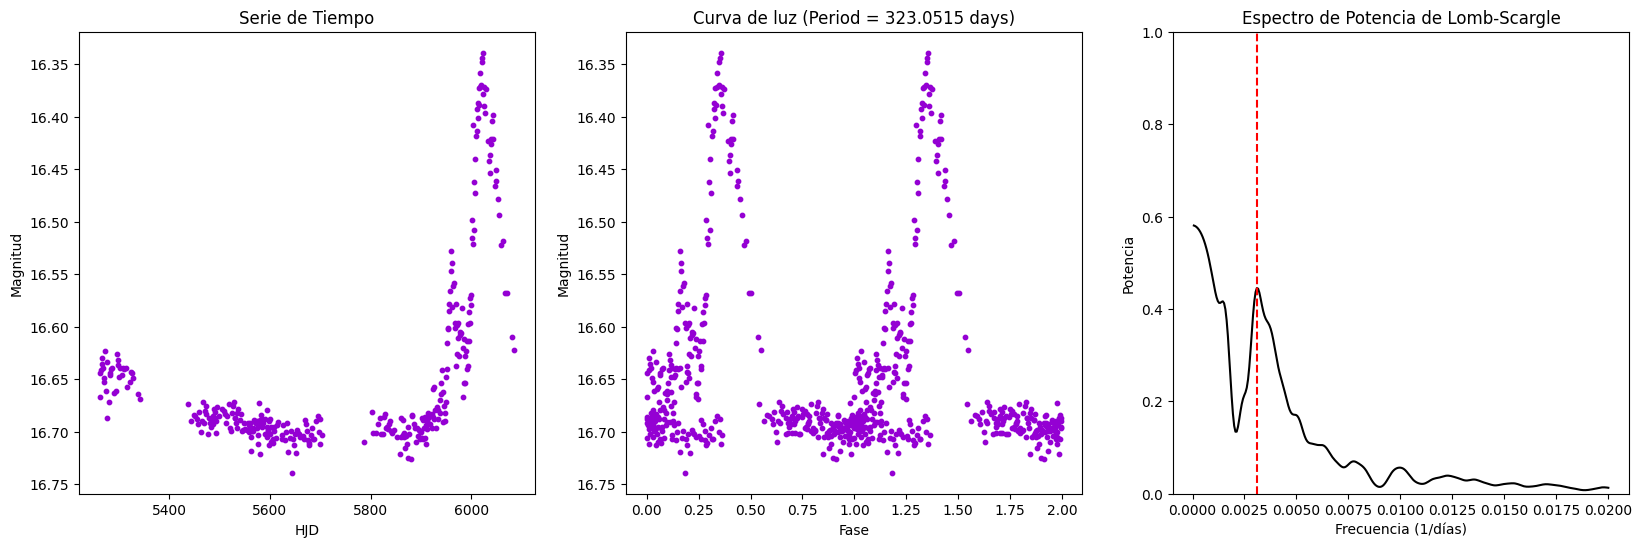

c:\users\daniel\appdata\local\programs\python\python38\lib\site-packages\astropy\timeseries\periodograms\lombscargle\implementations\fast_impl.py:102: RuntimeWarning: invalid value encountered in divide
  tan_2omega_tau = (S2 - 2 * S * C) / (C2 - (C * C - S * S))


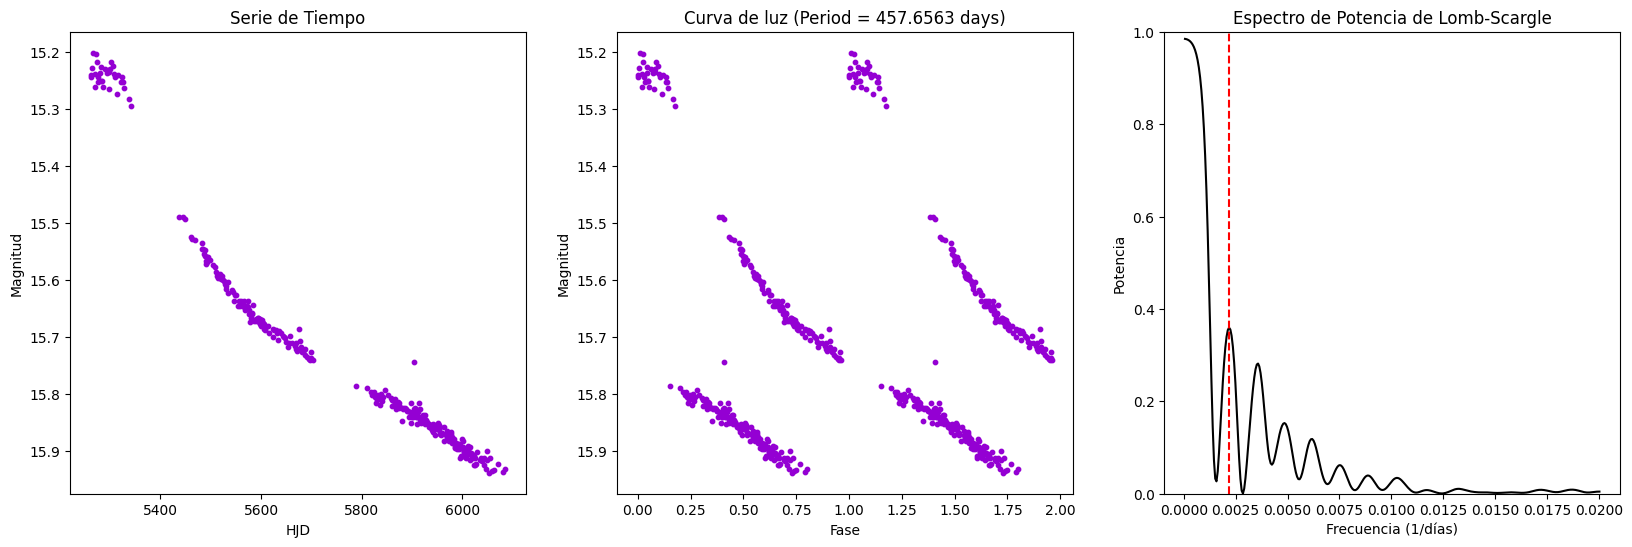

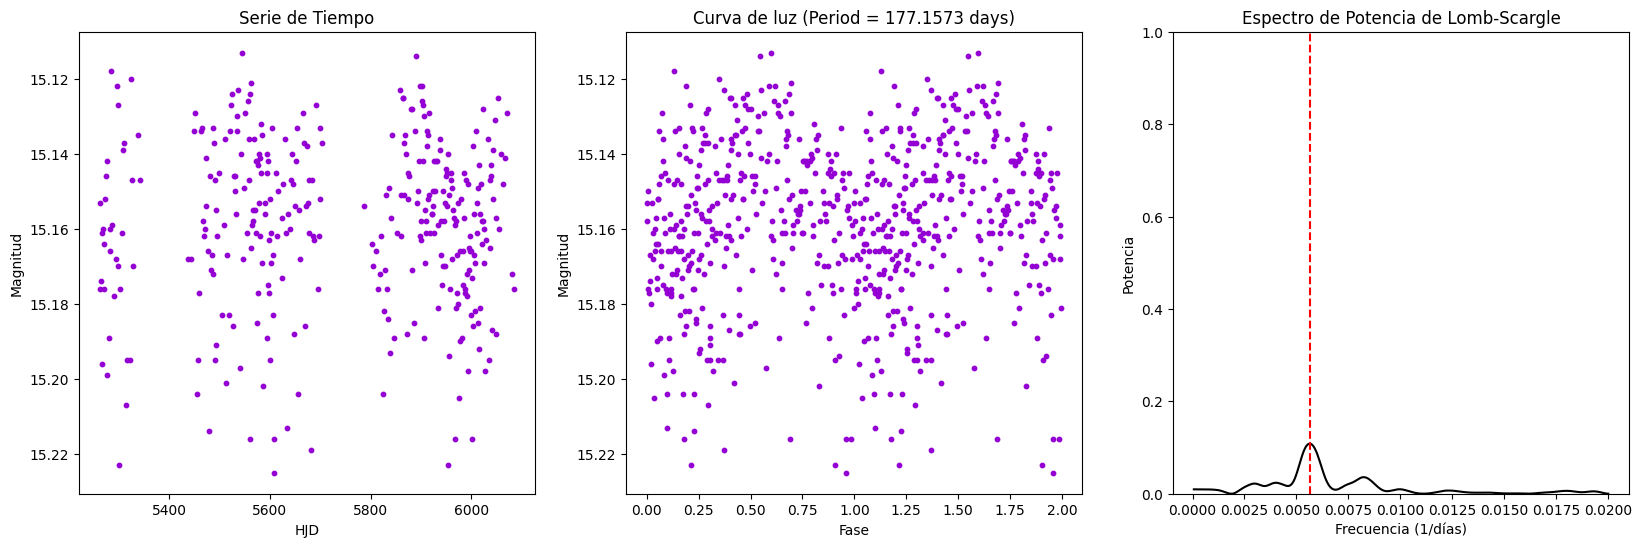

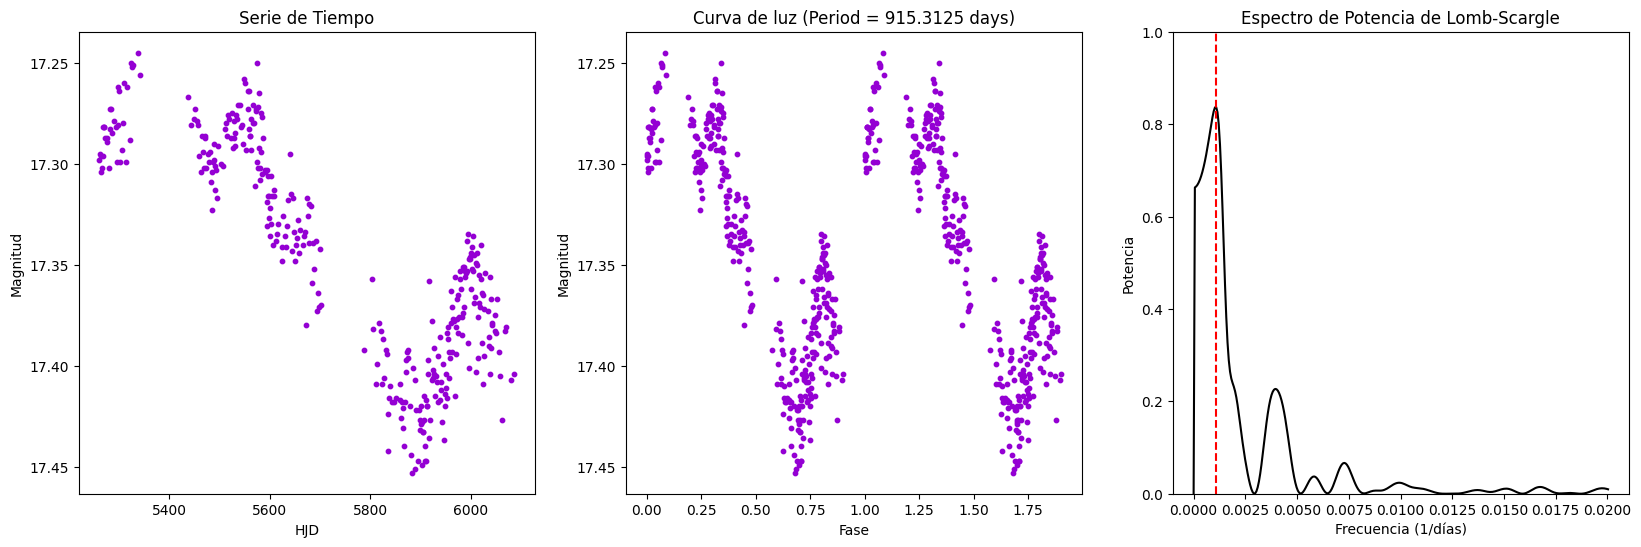

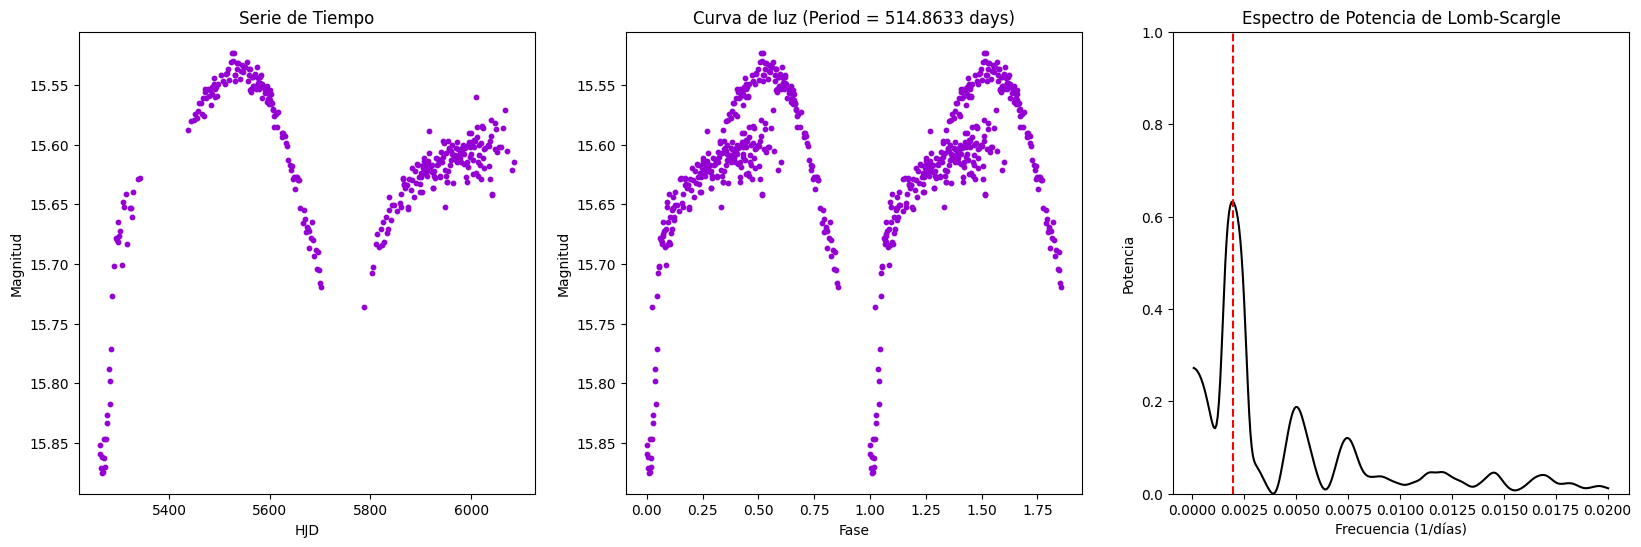

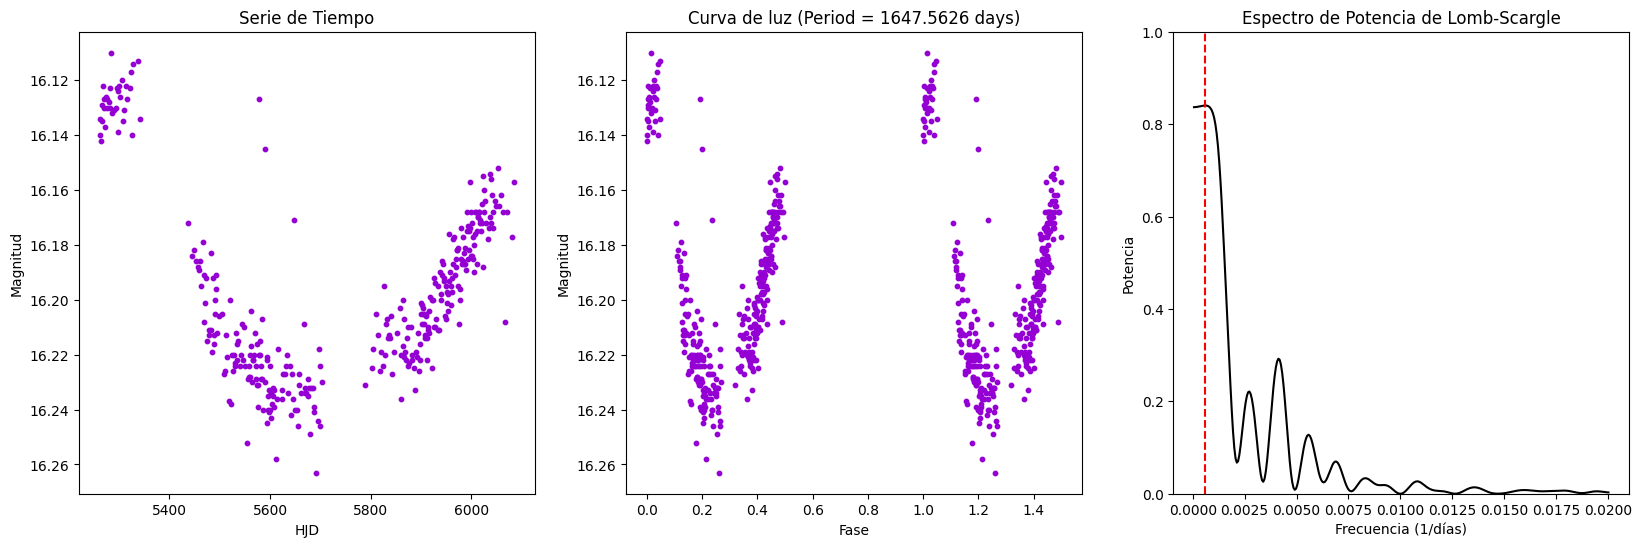

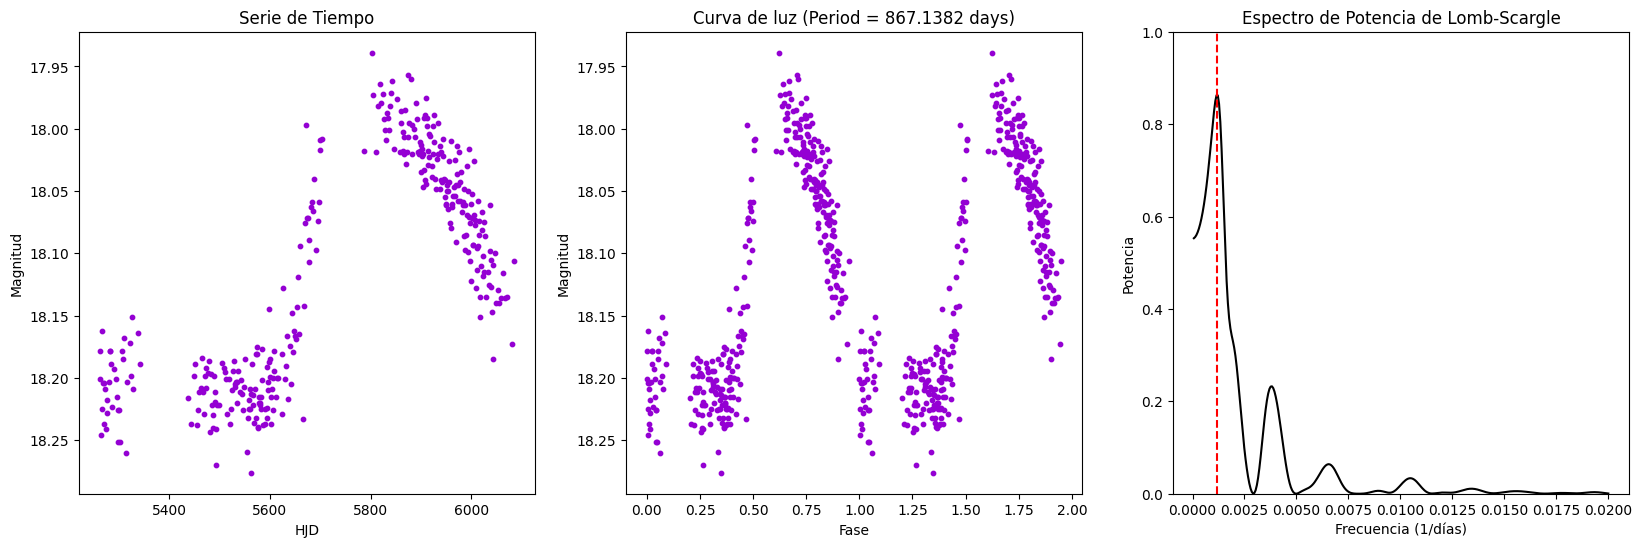

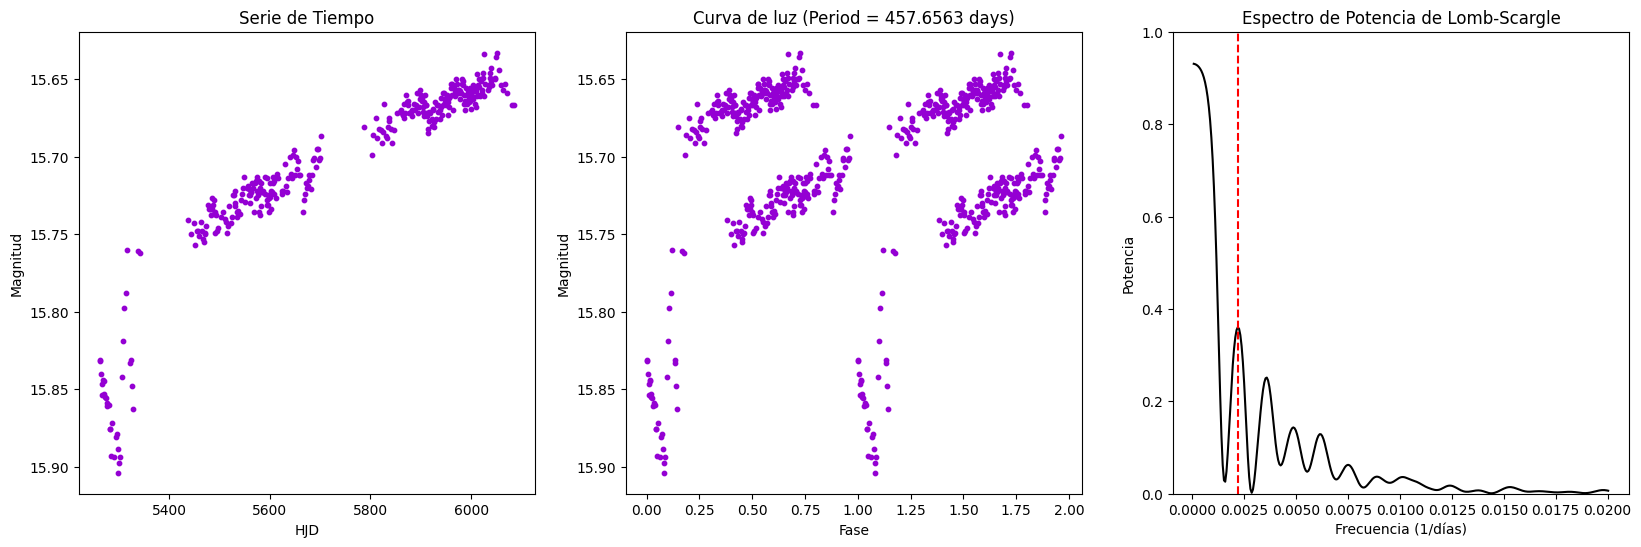

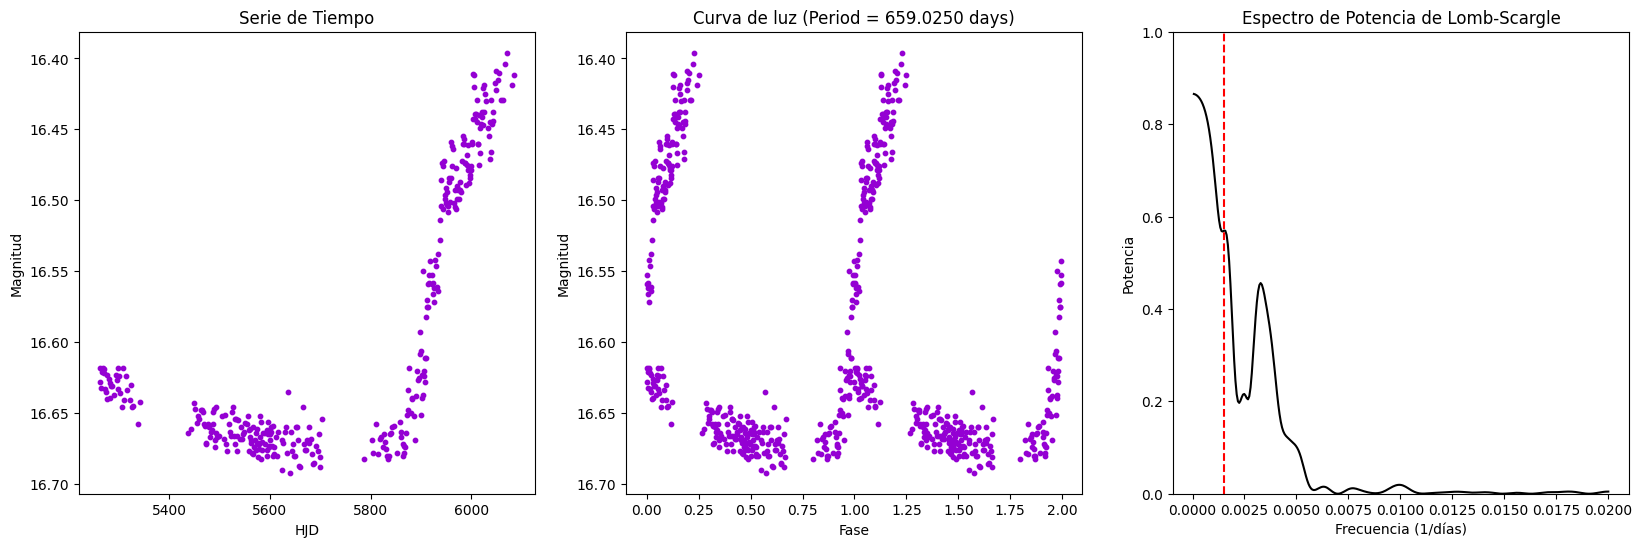

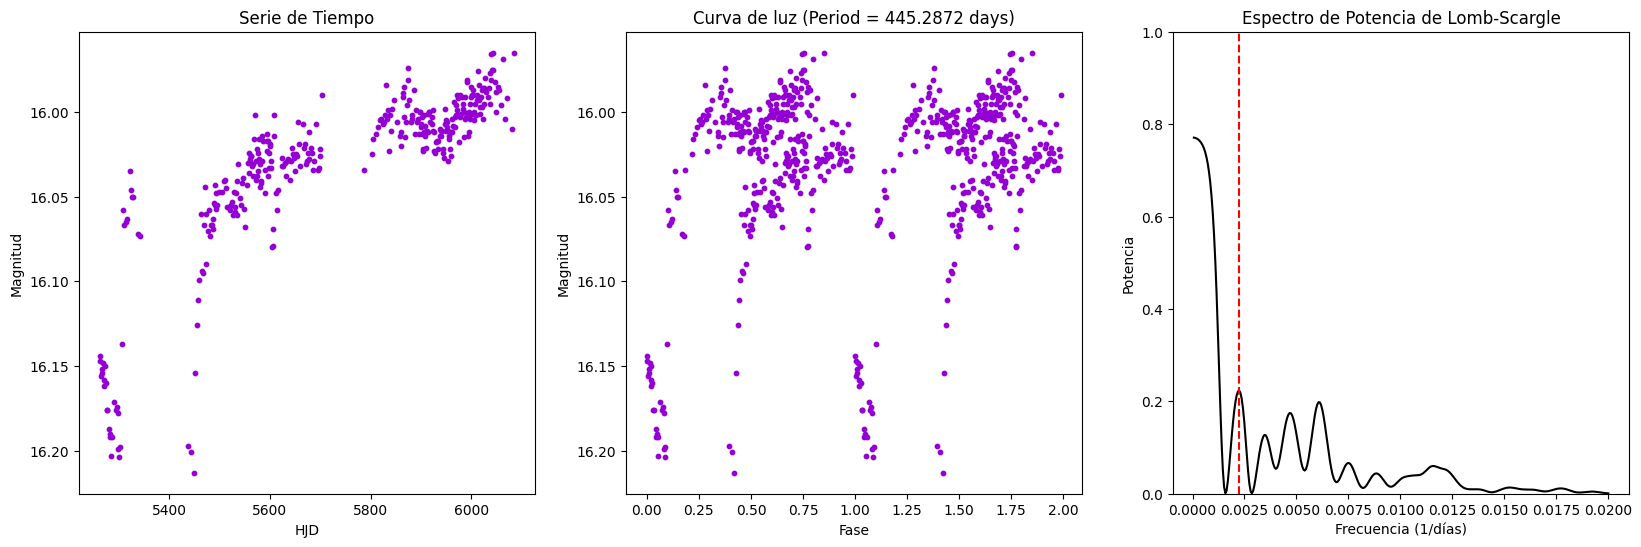

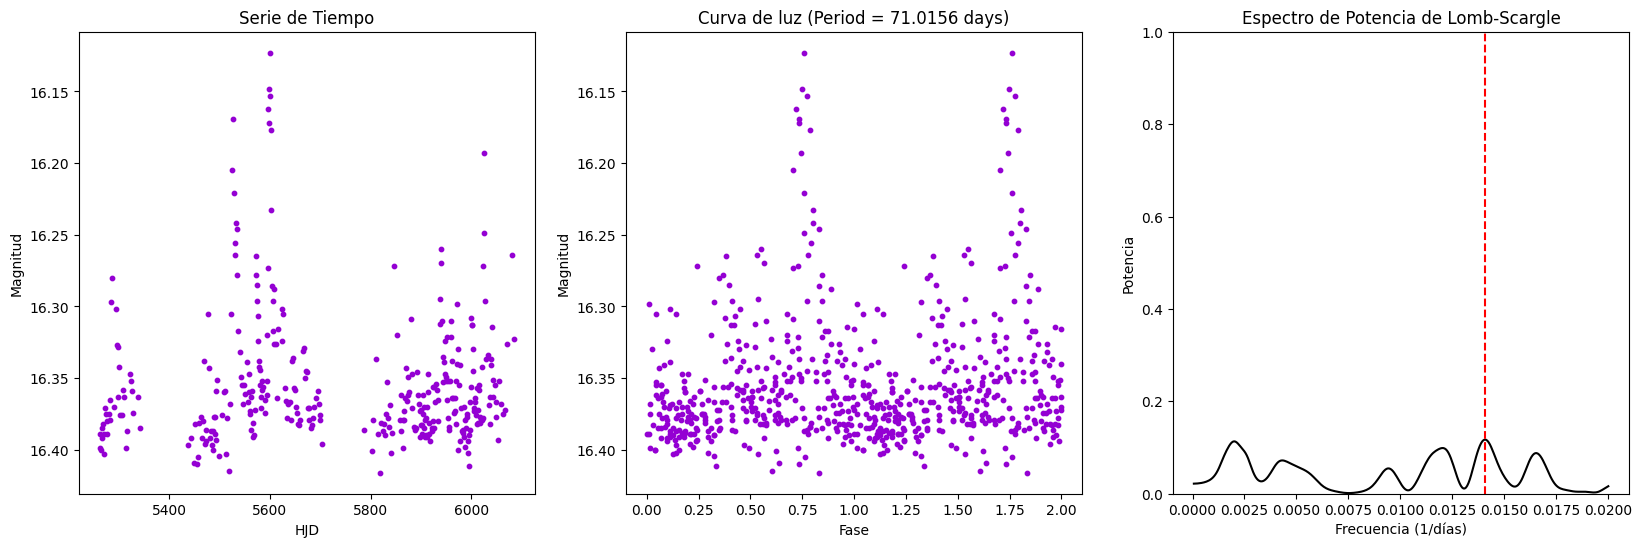

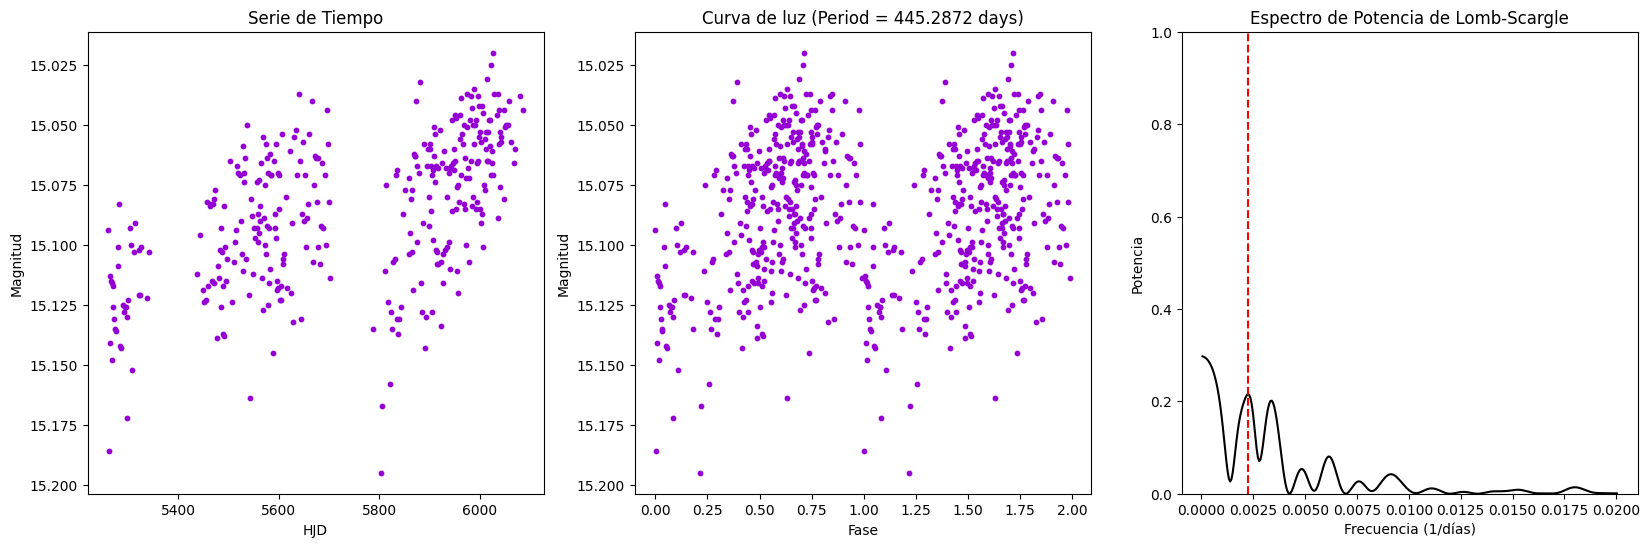

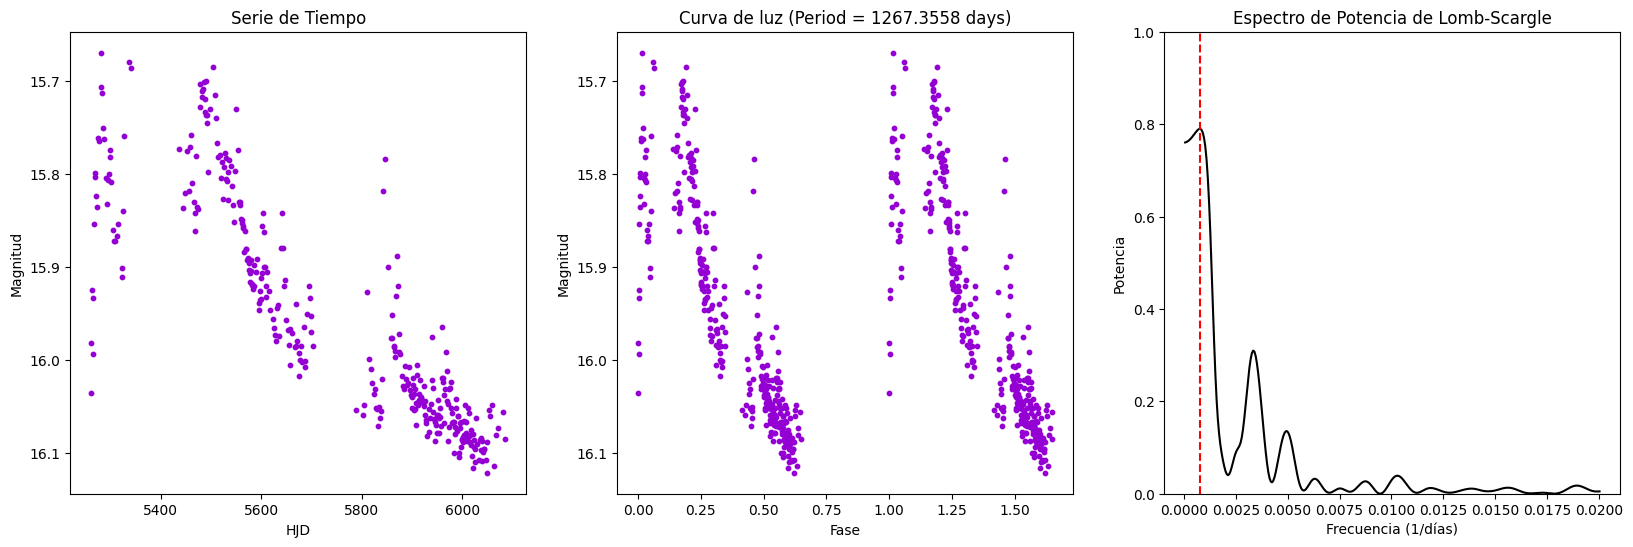

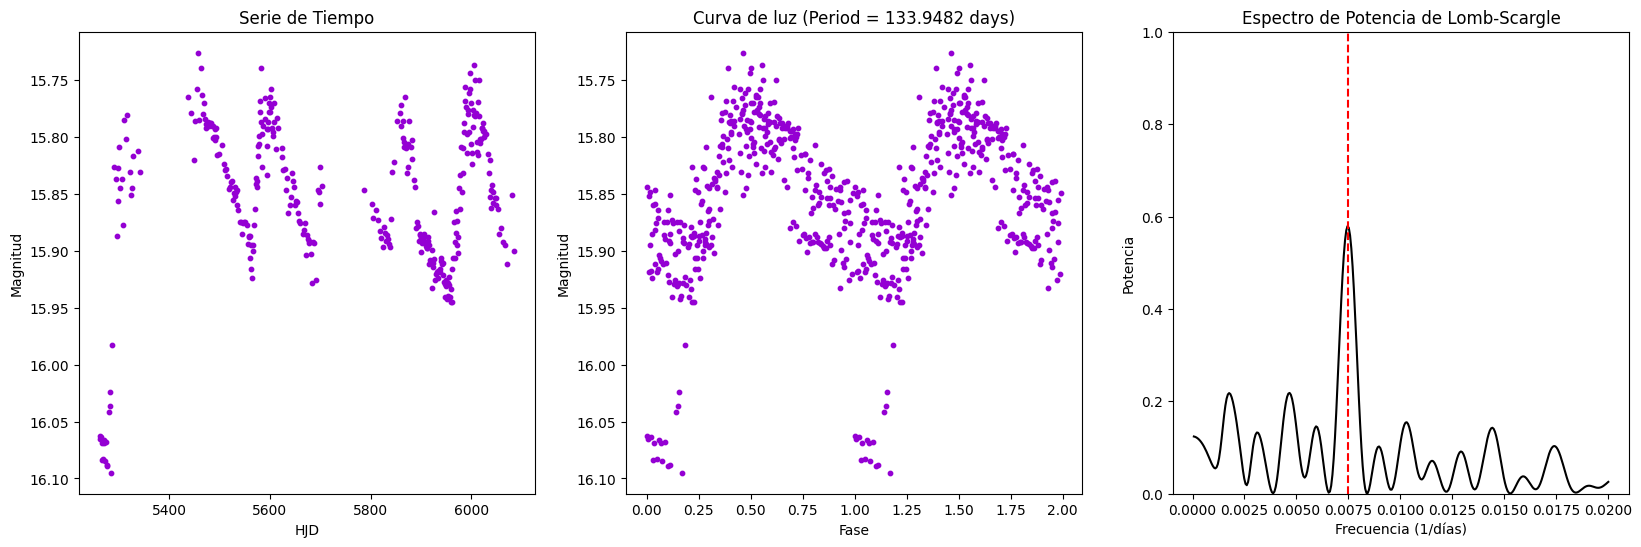

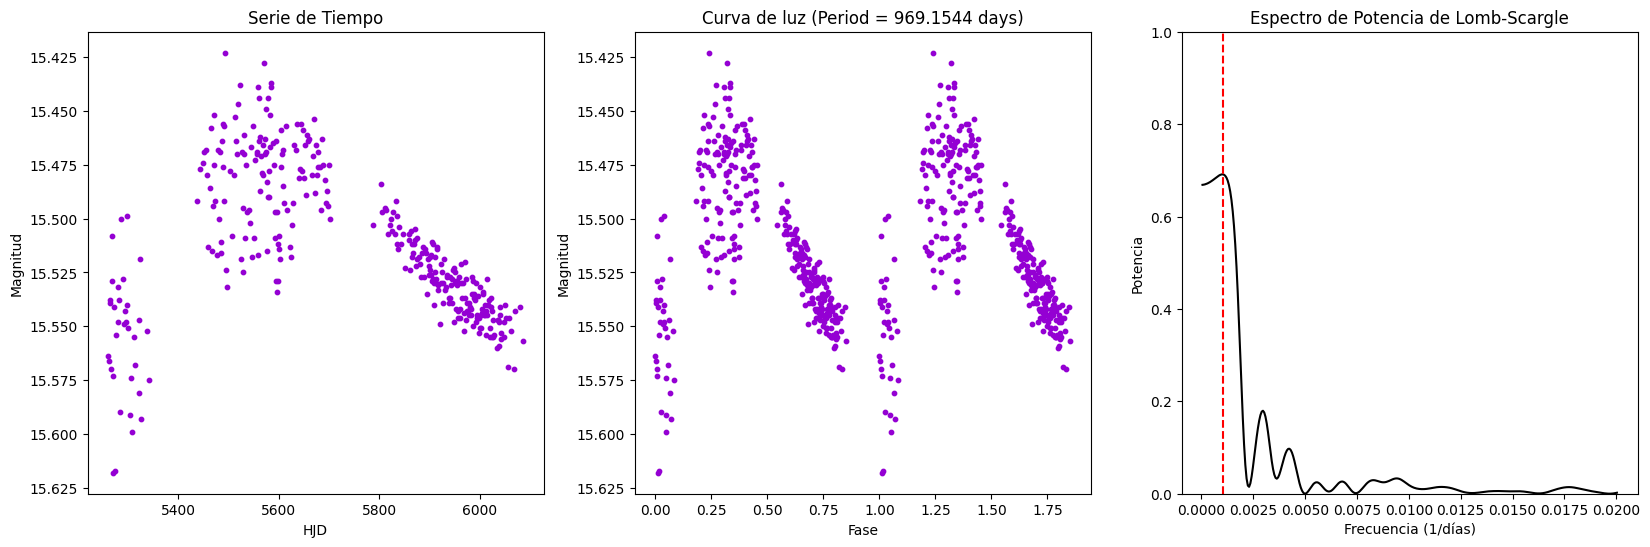

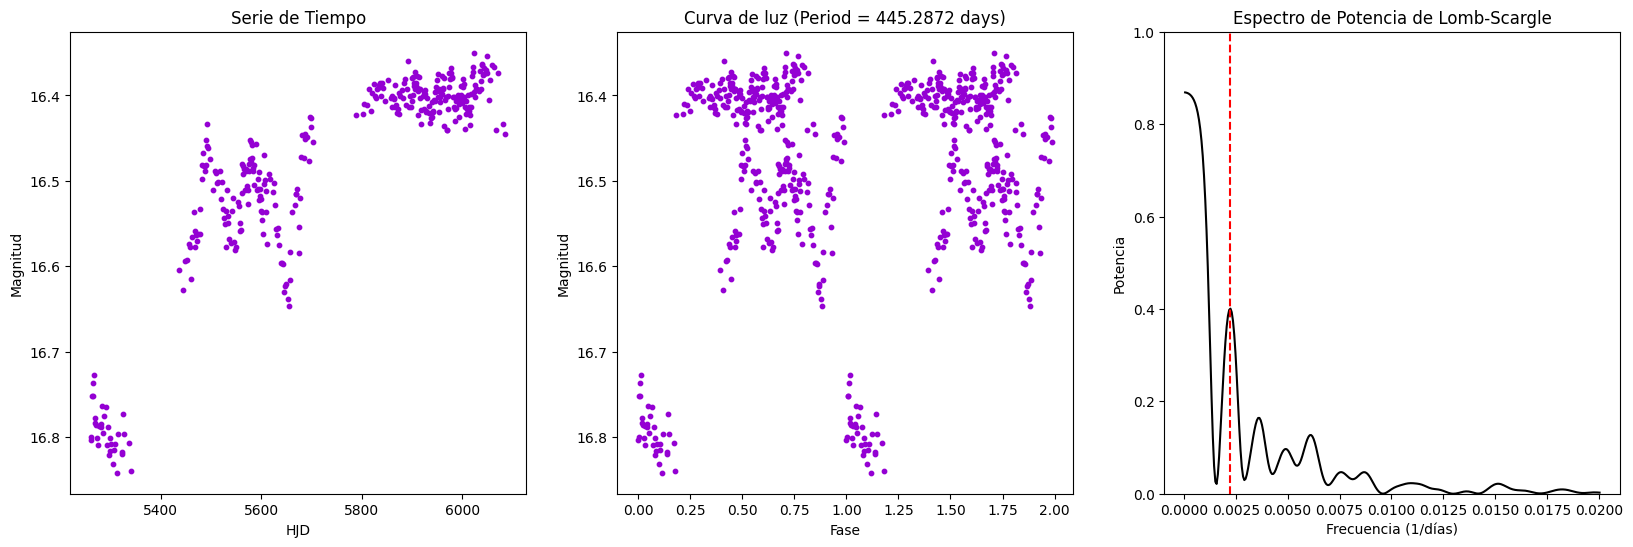

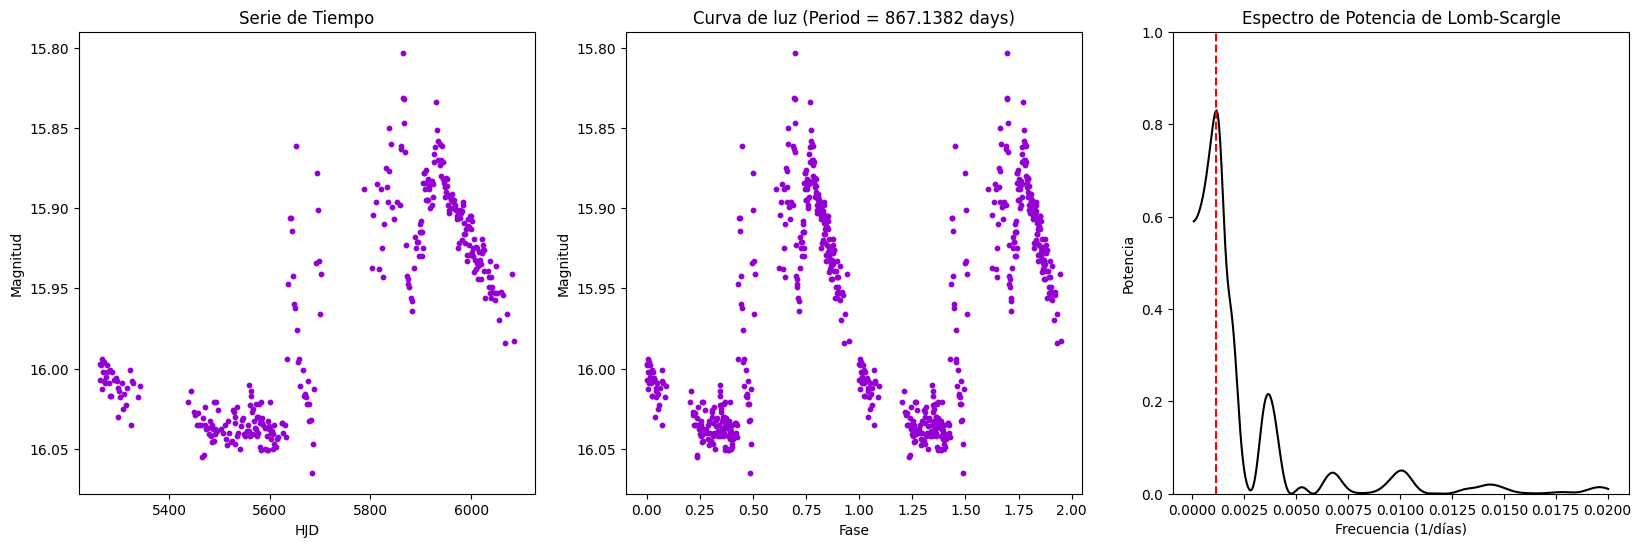

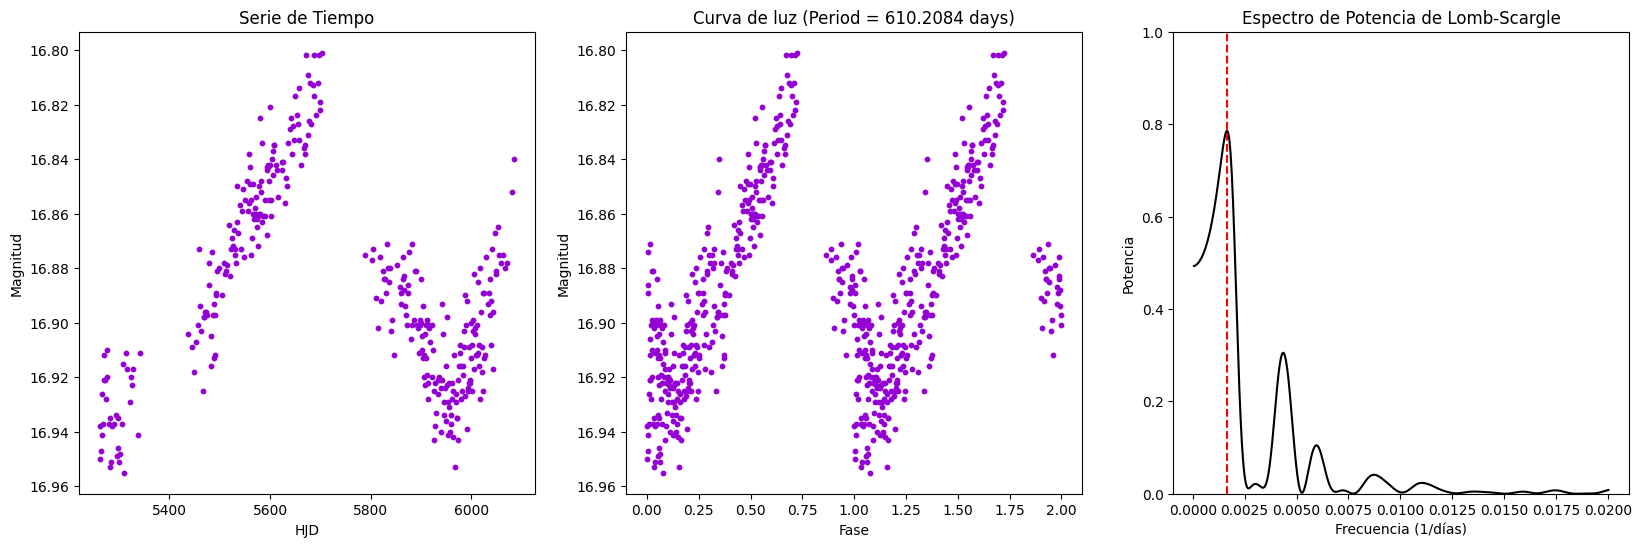

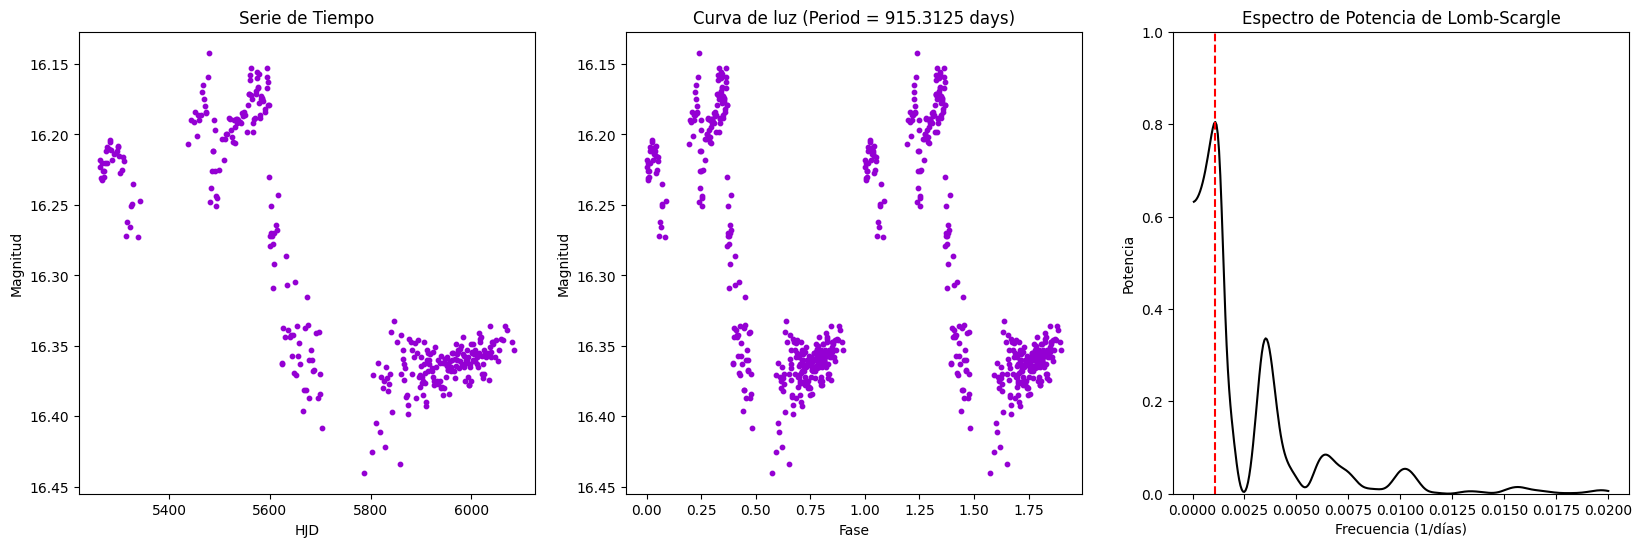

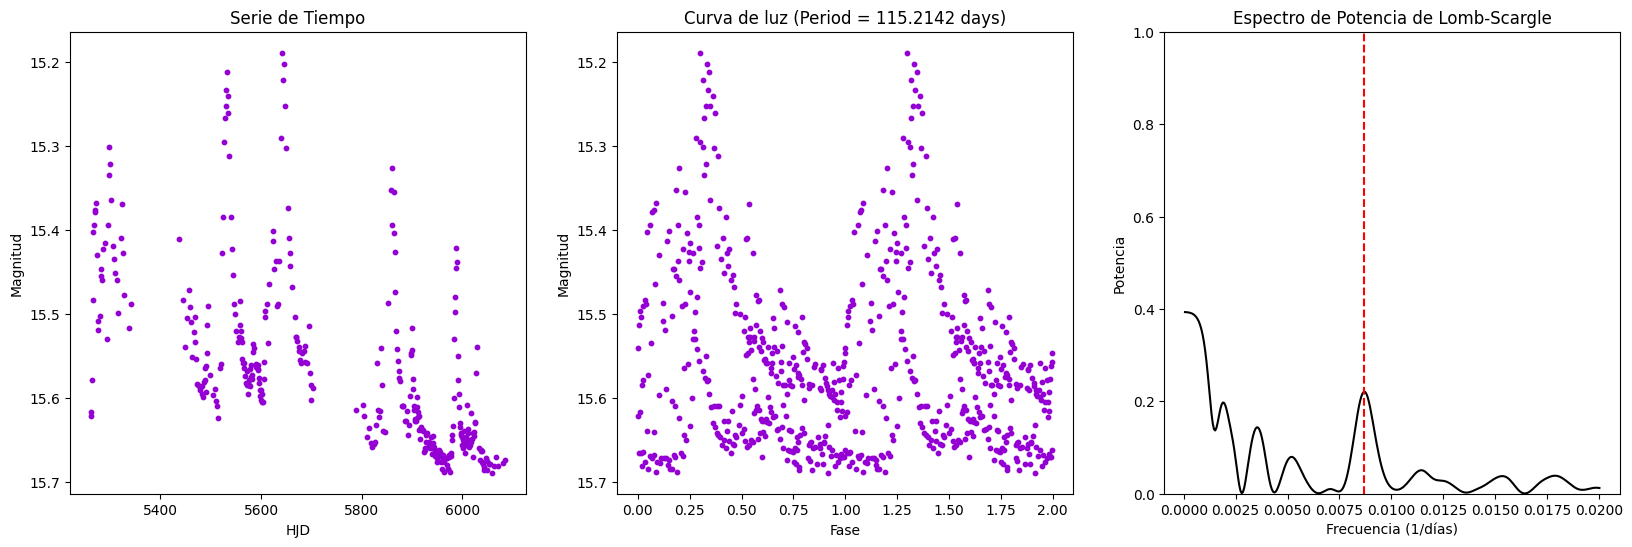

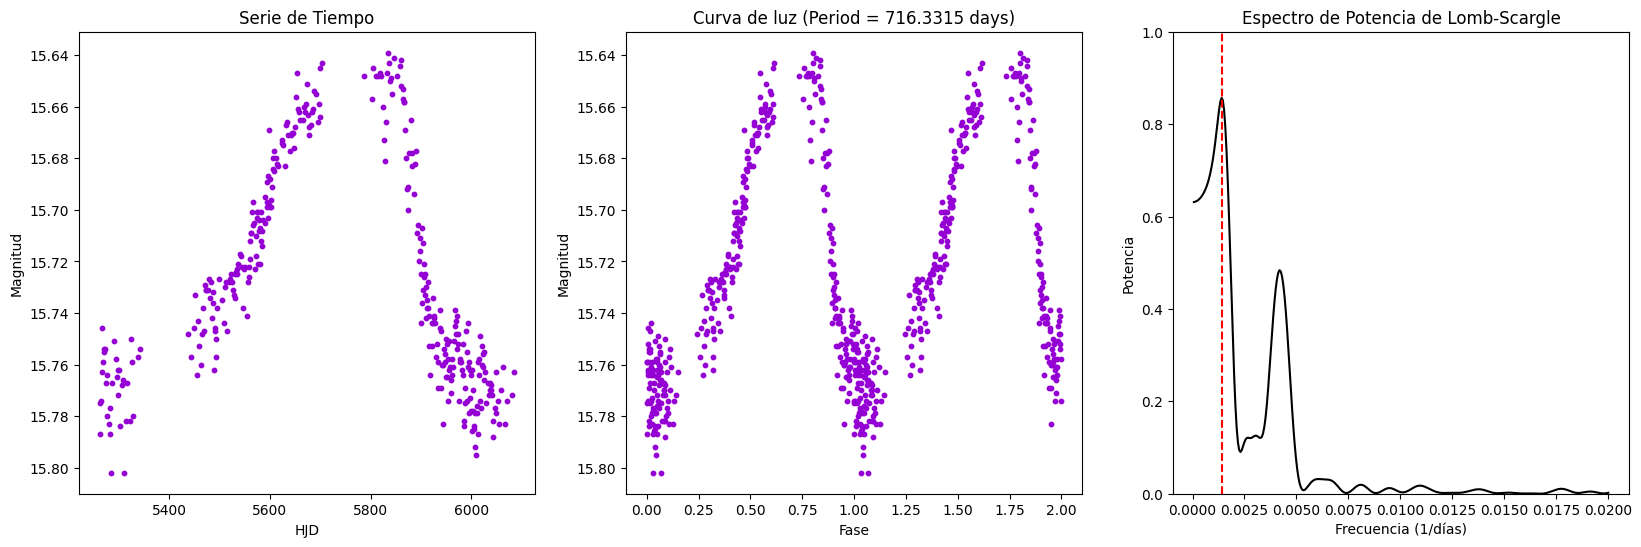

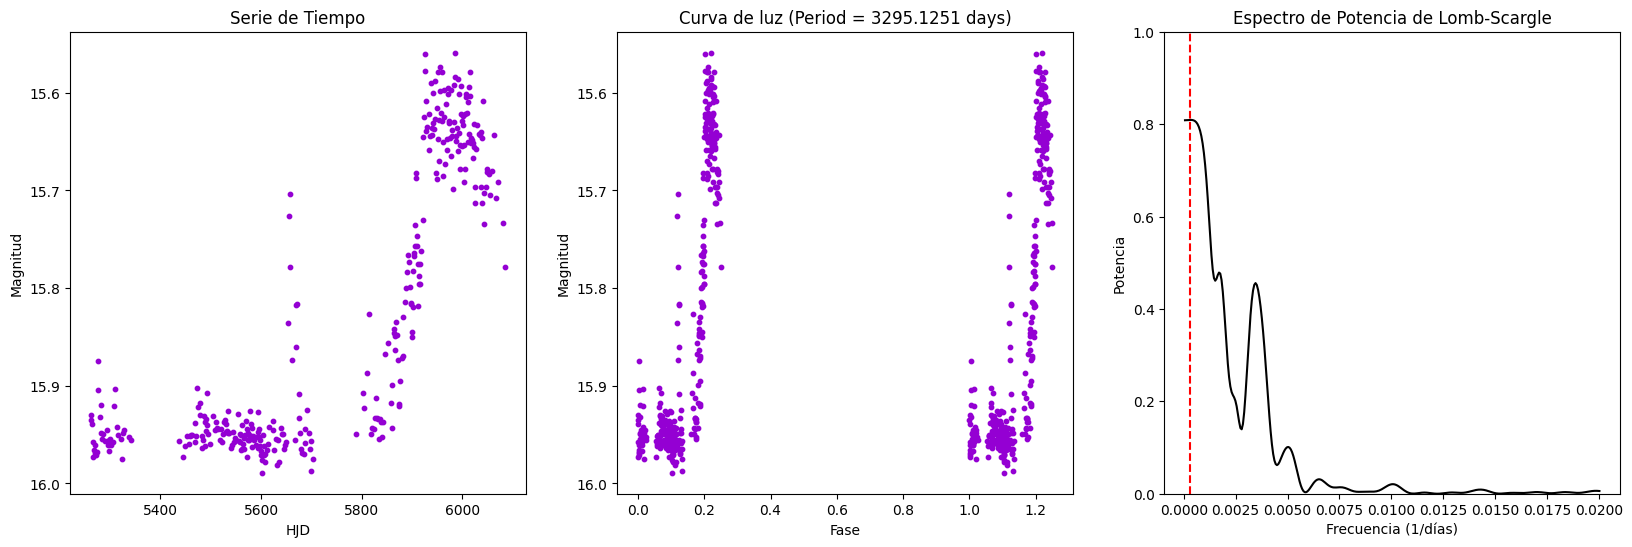

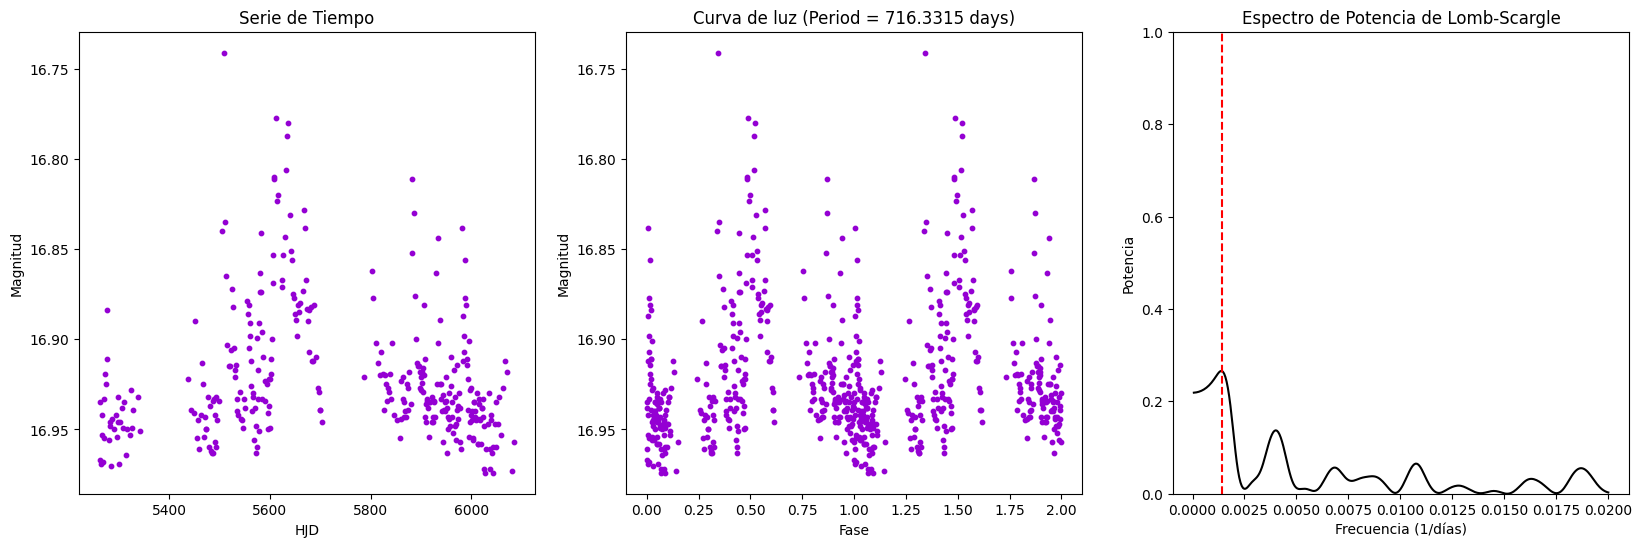

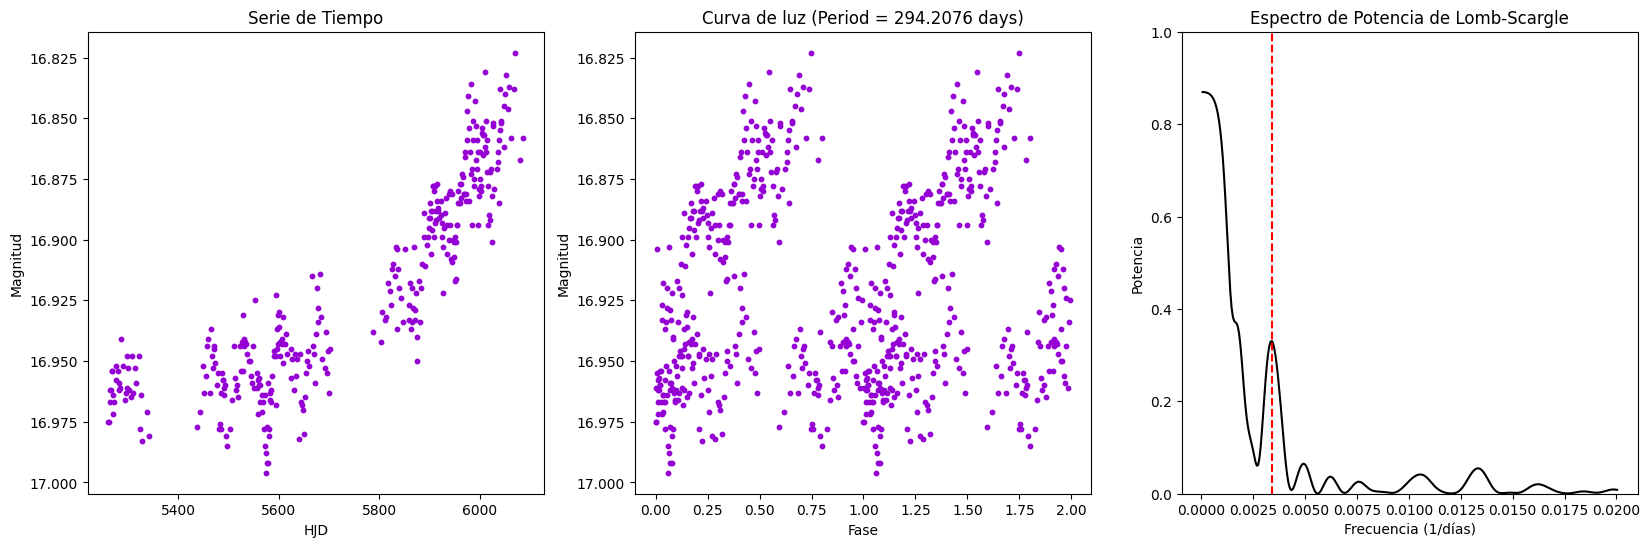

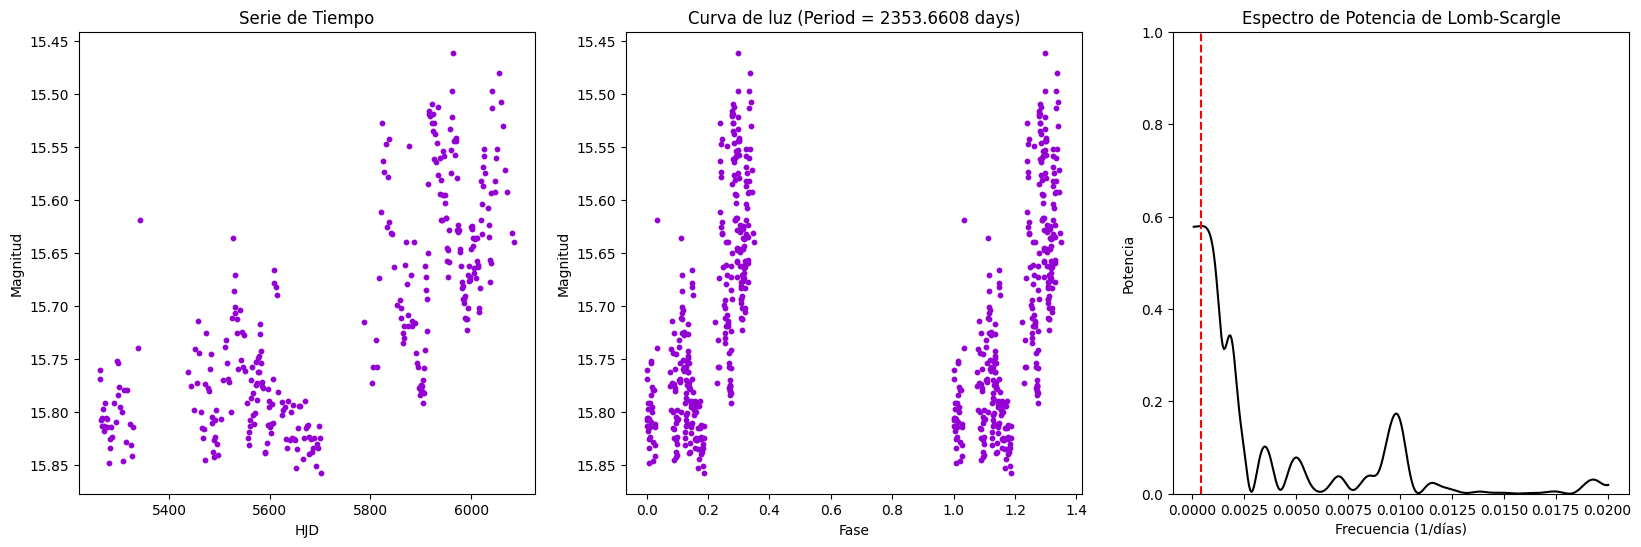

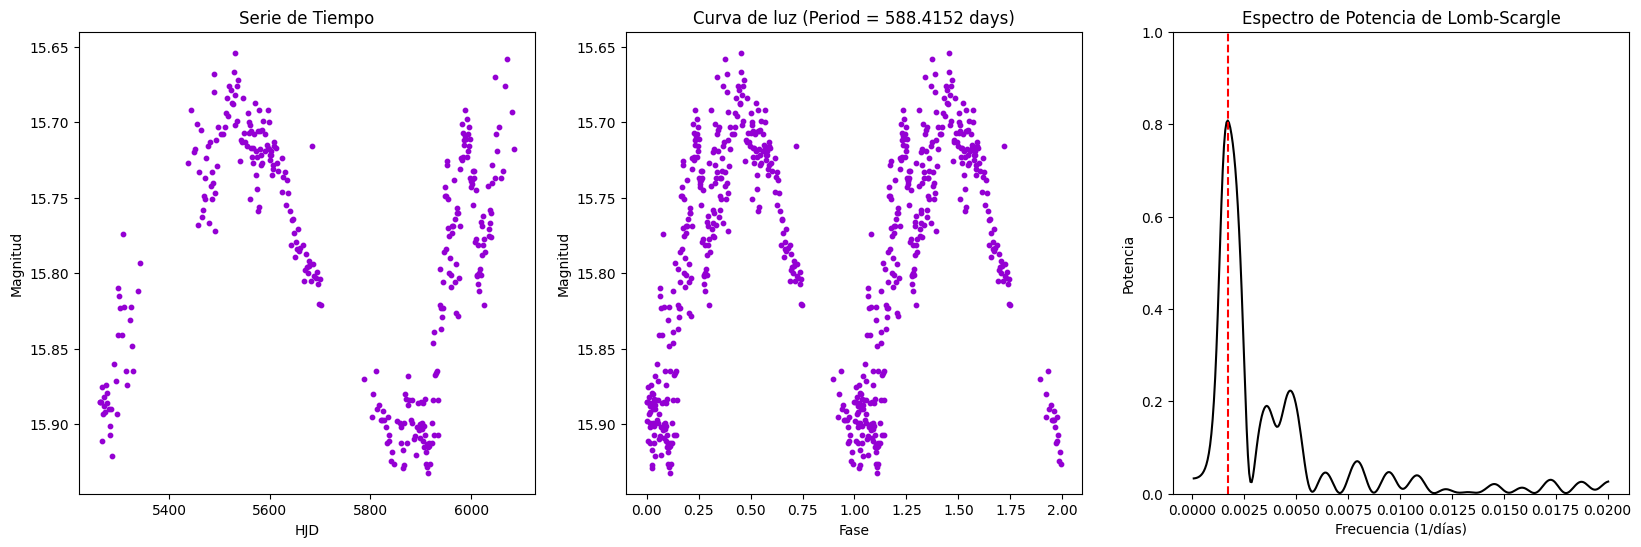

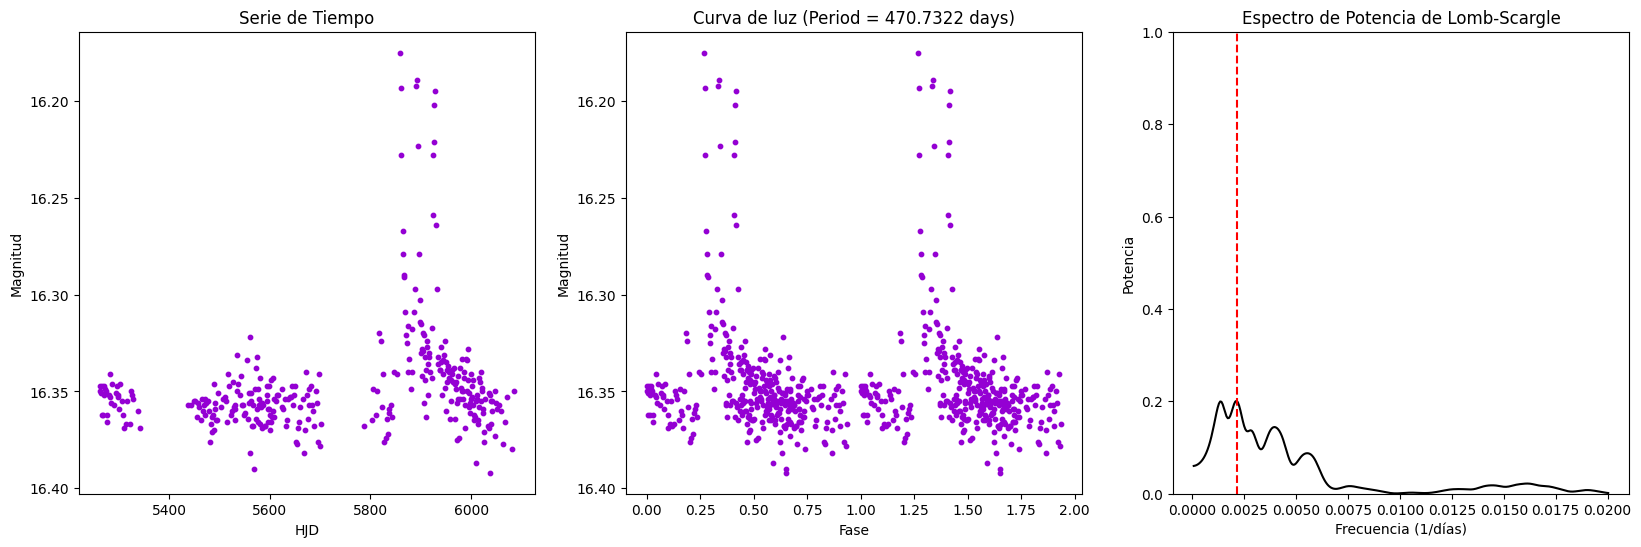

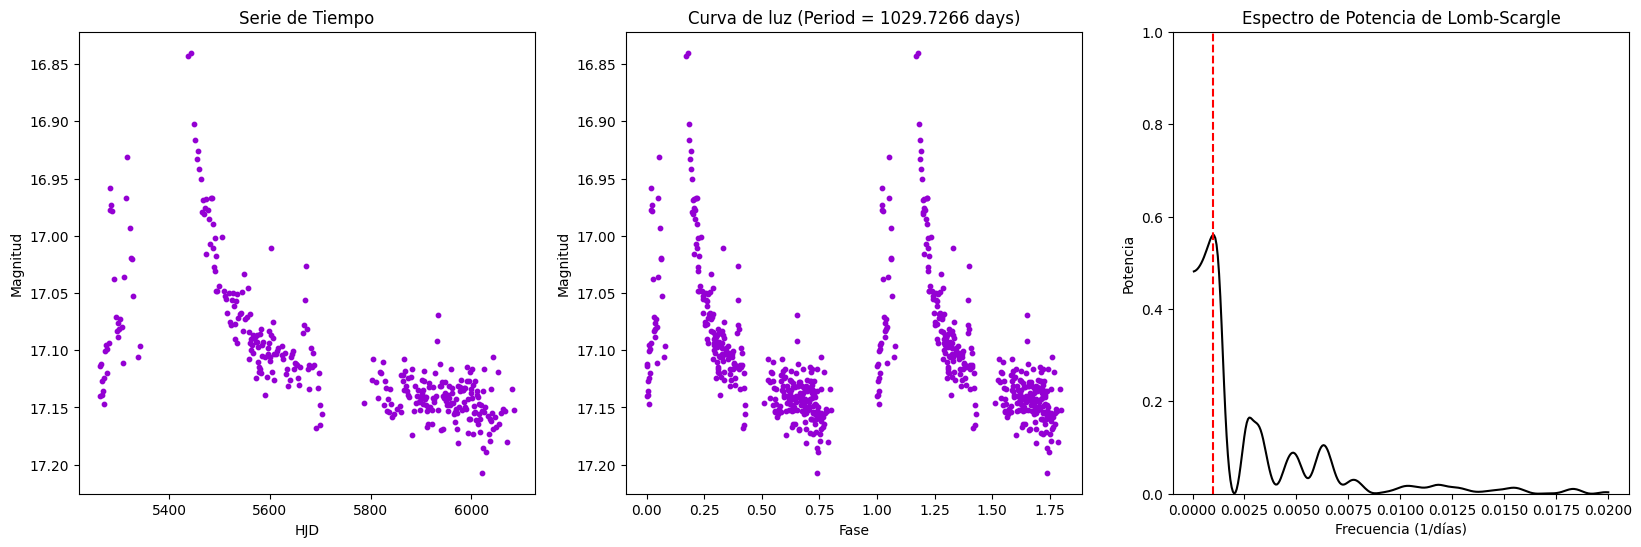

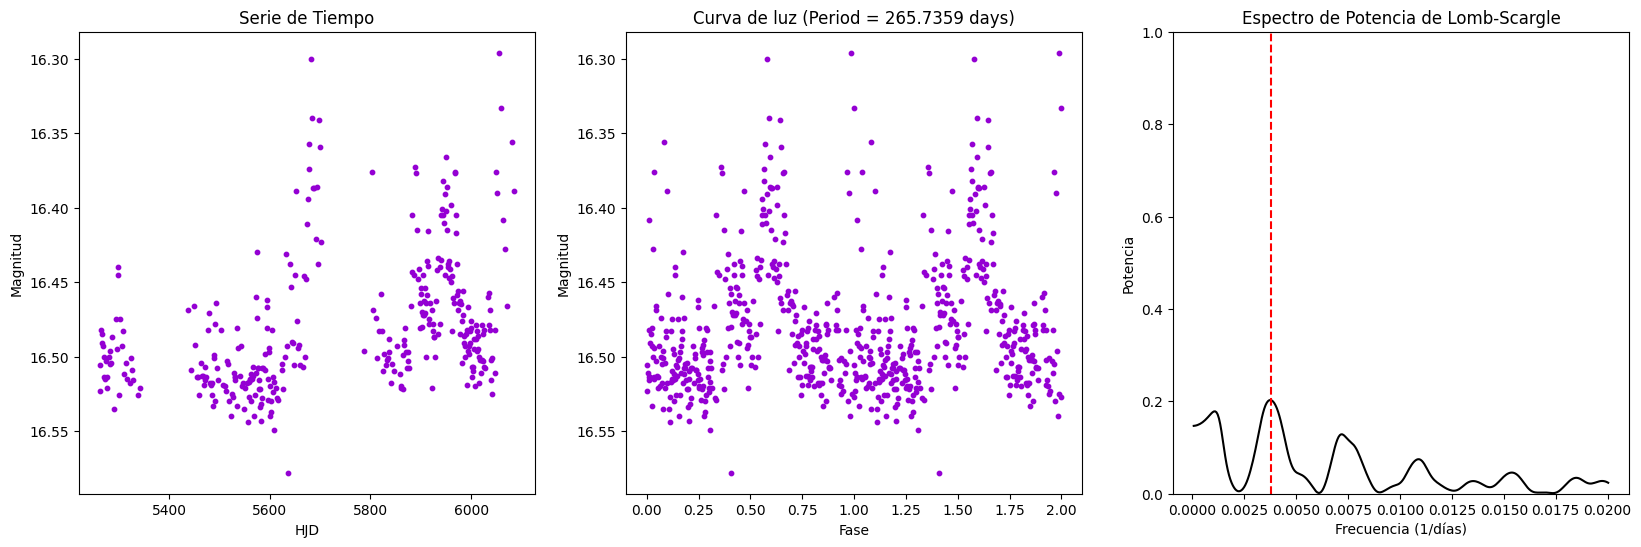

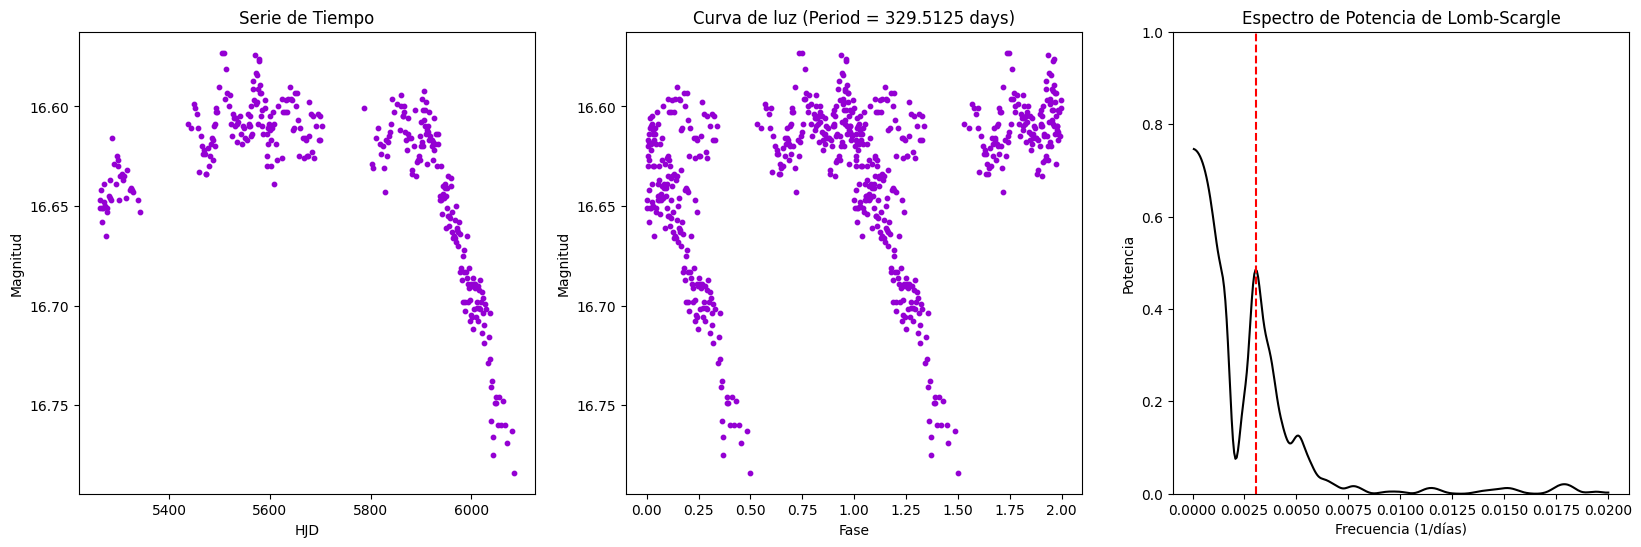

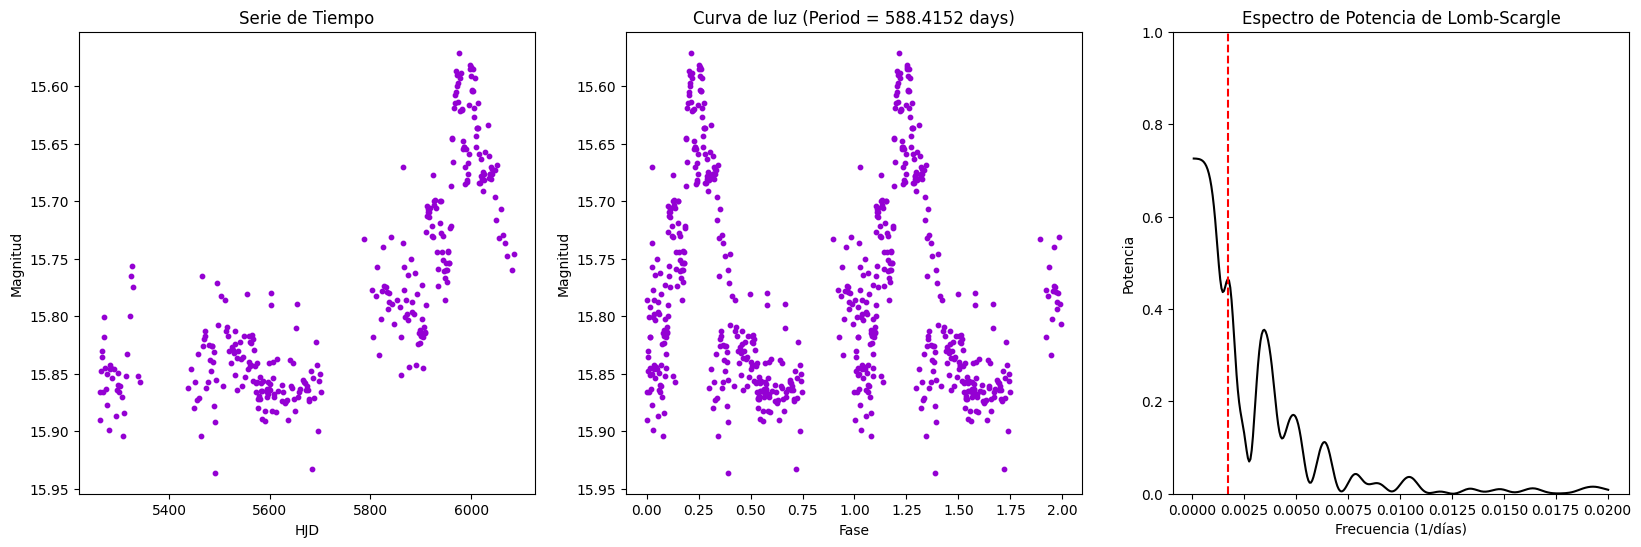

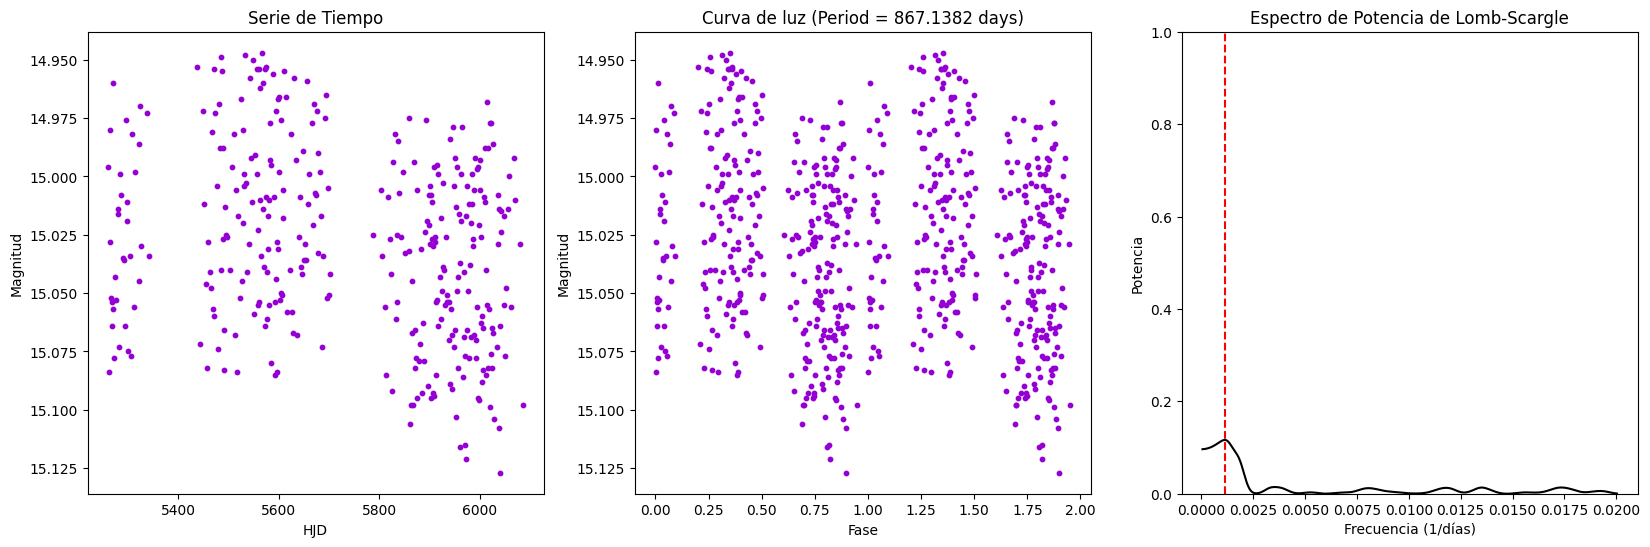

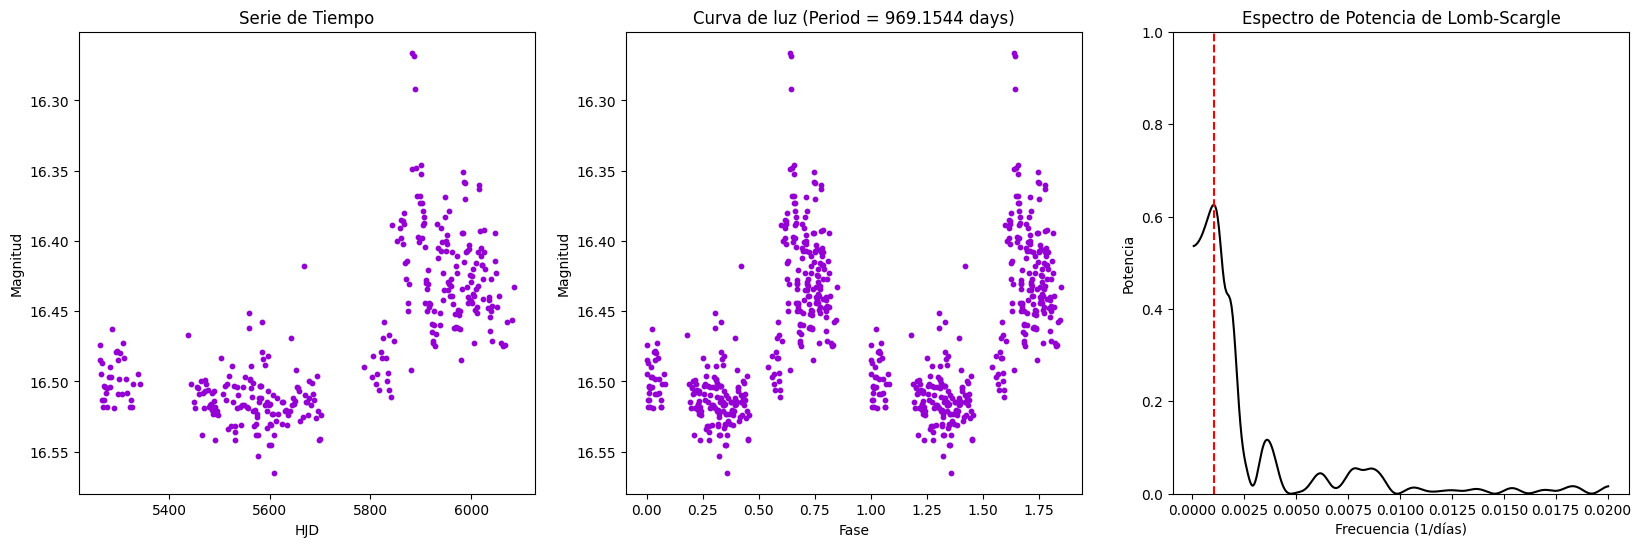

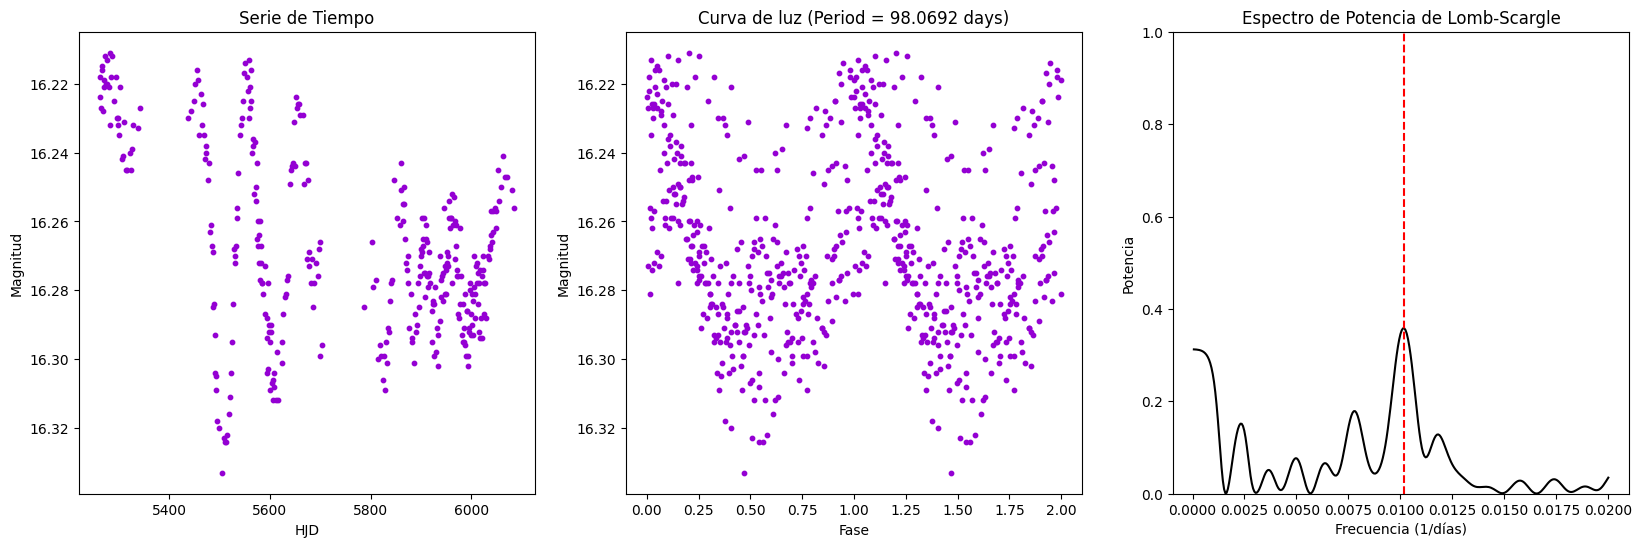

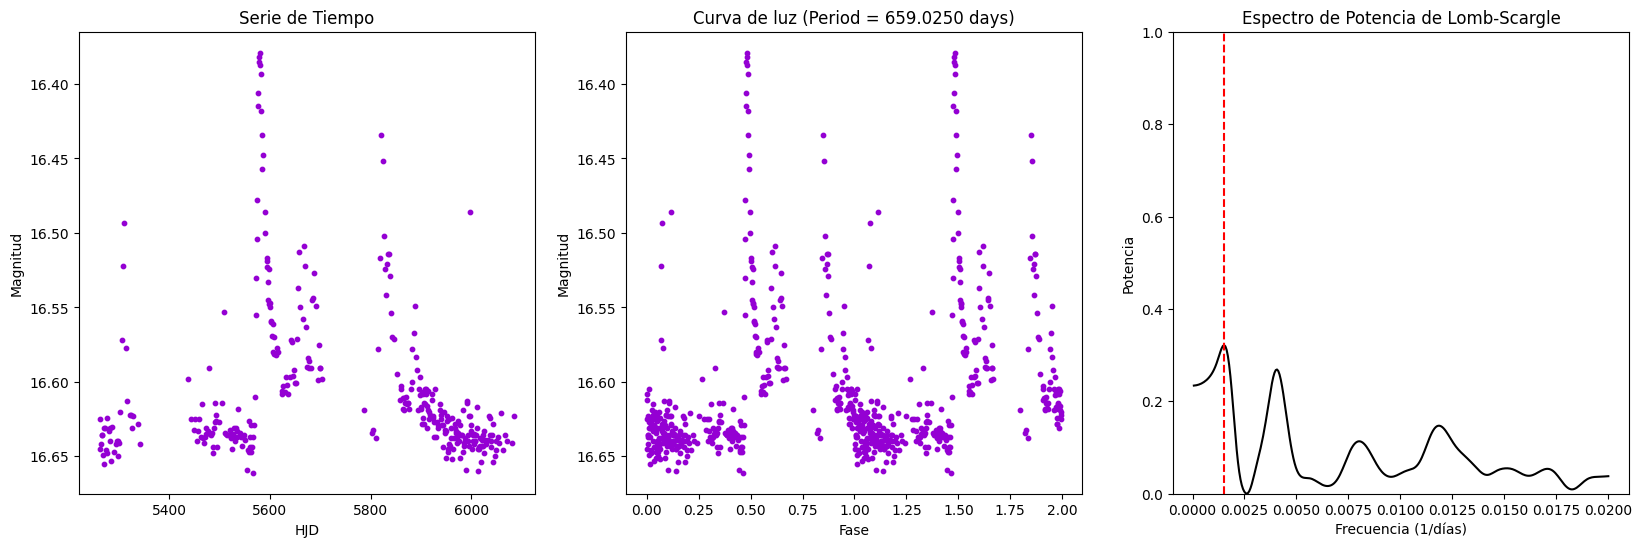

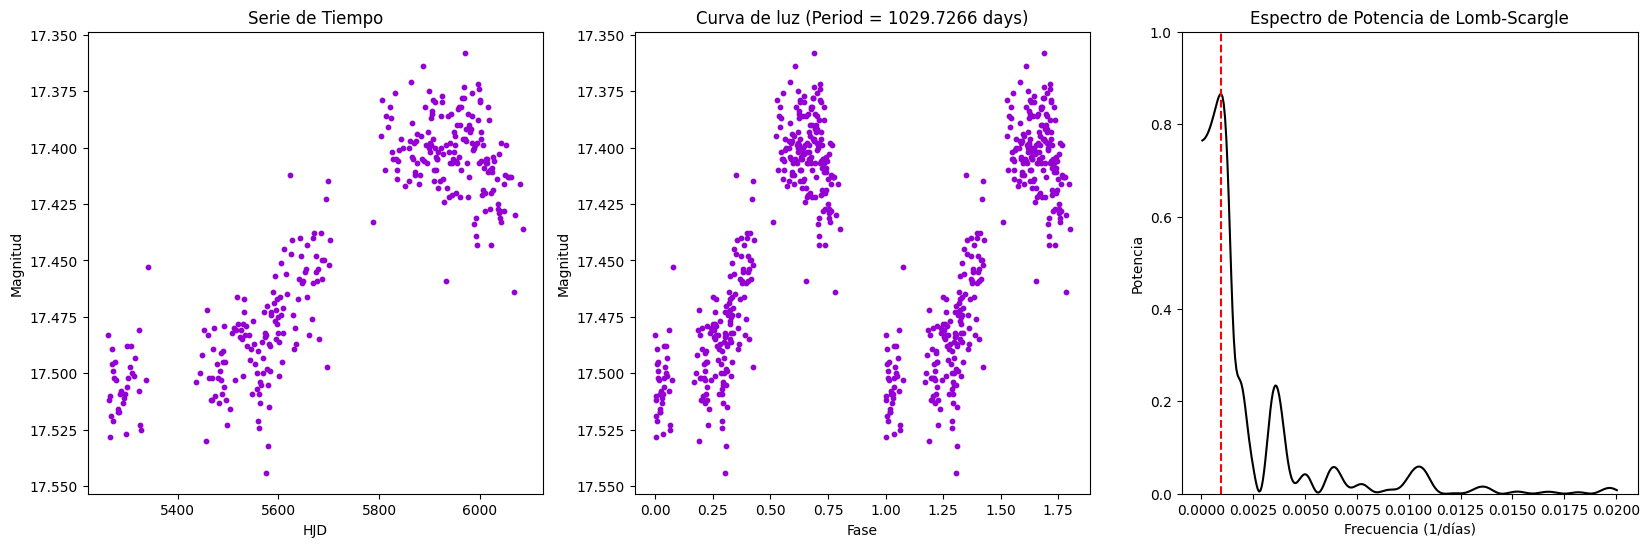

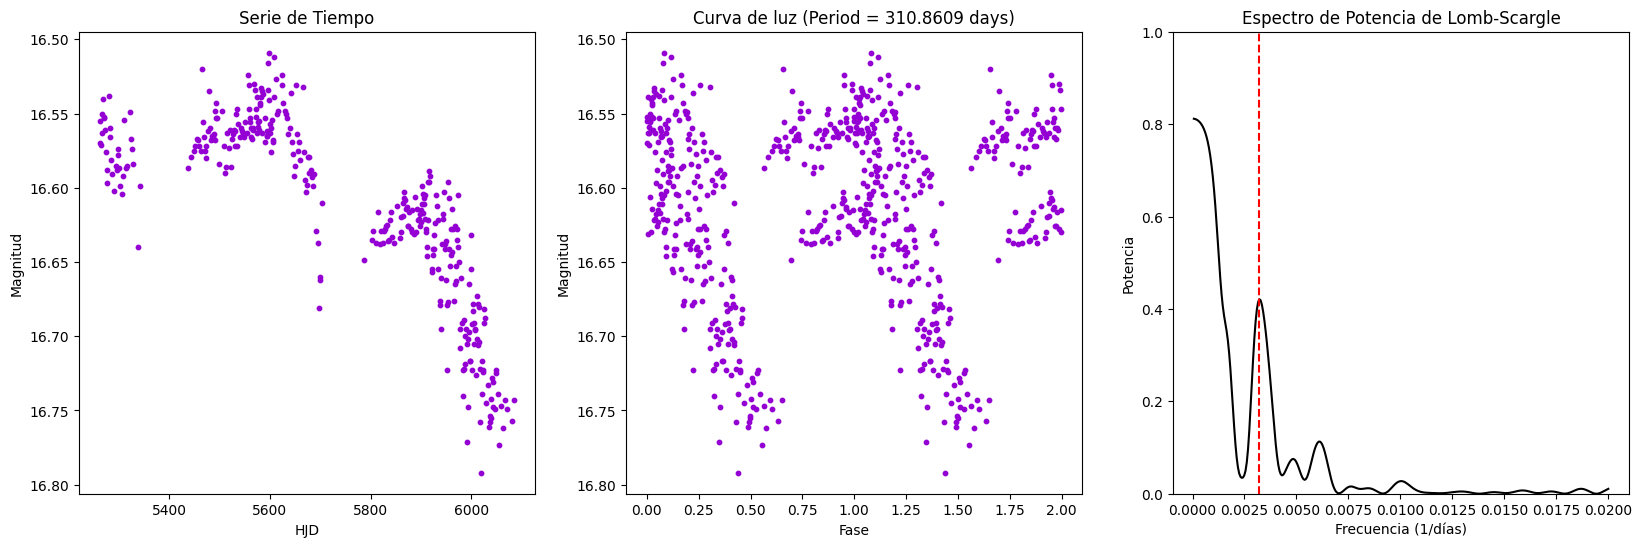

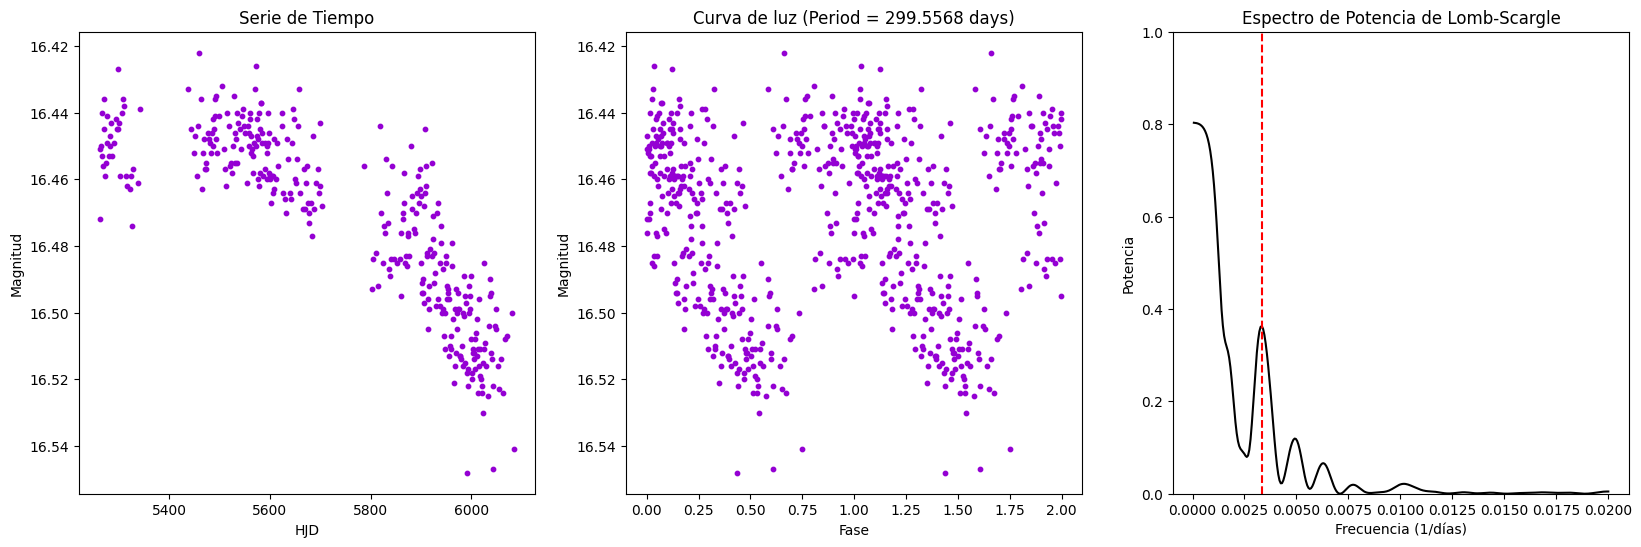

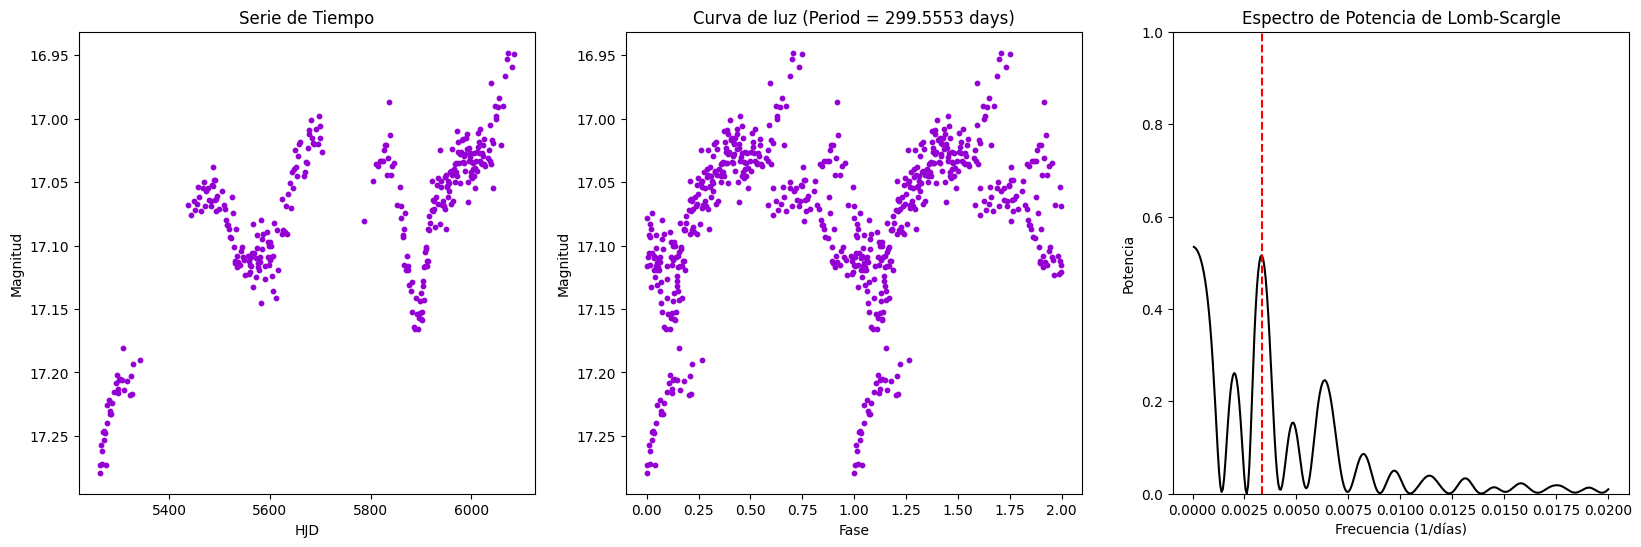

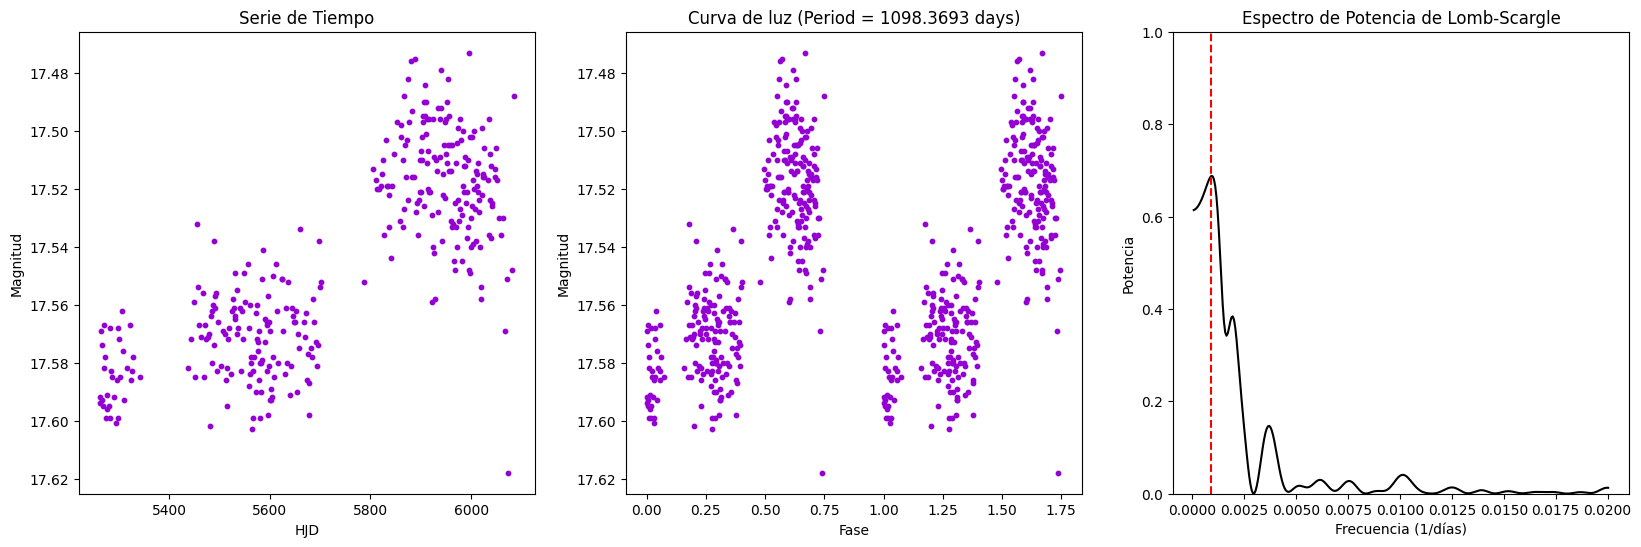

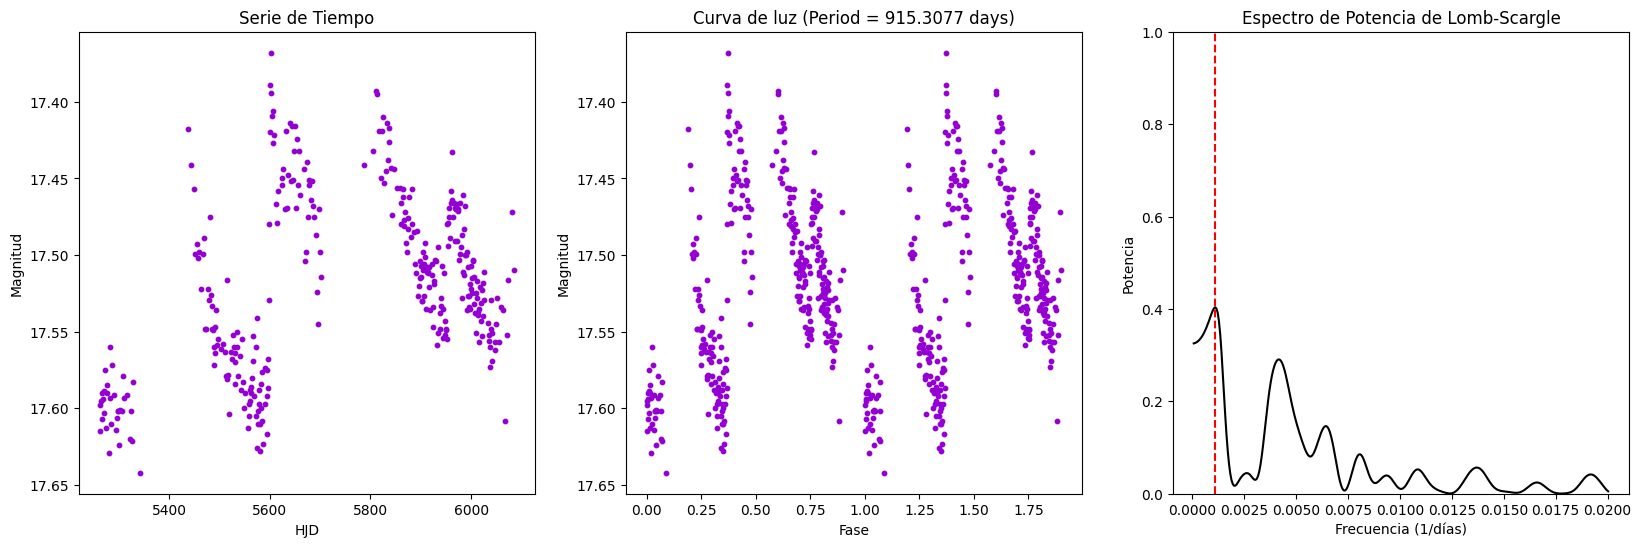

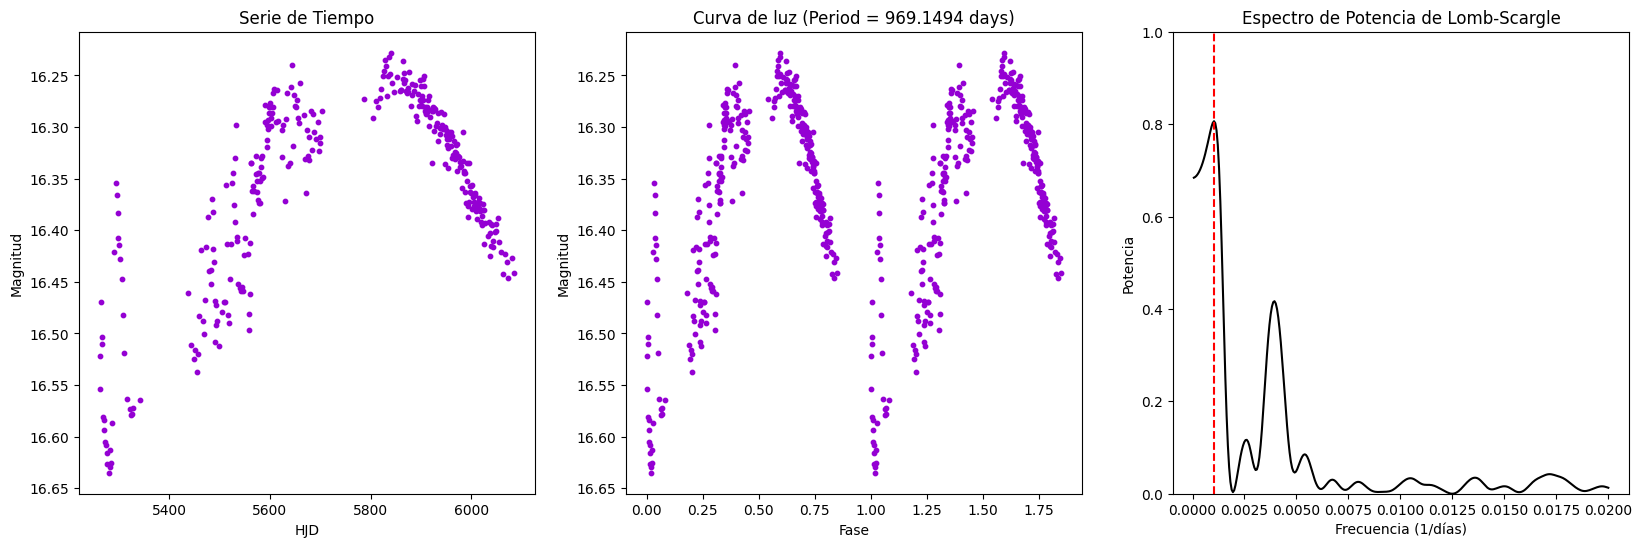

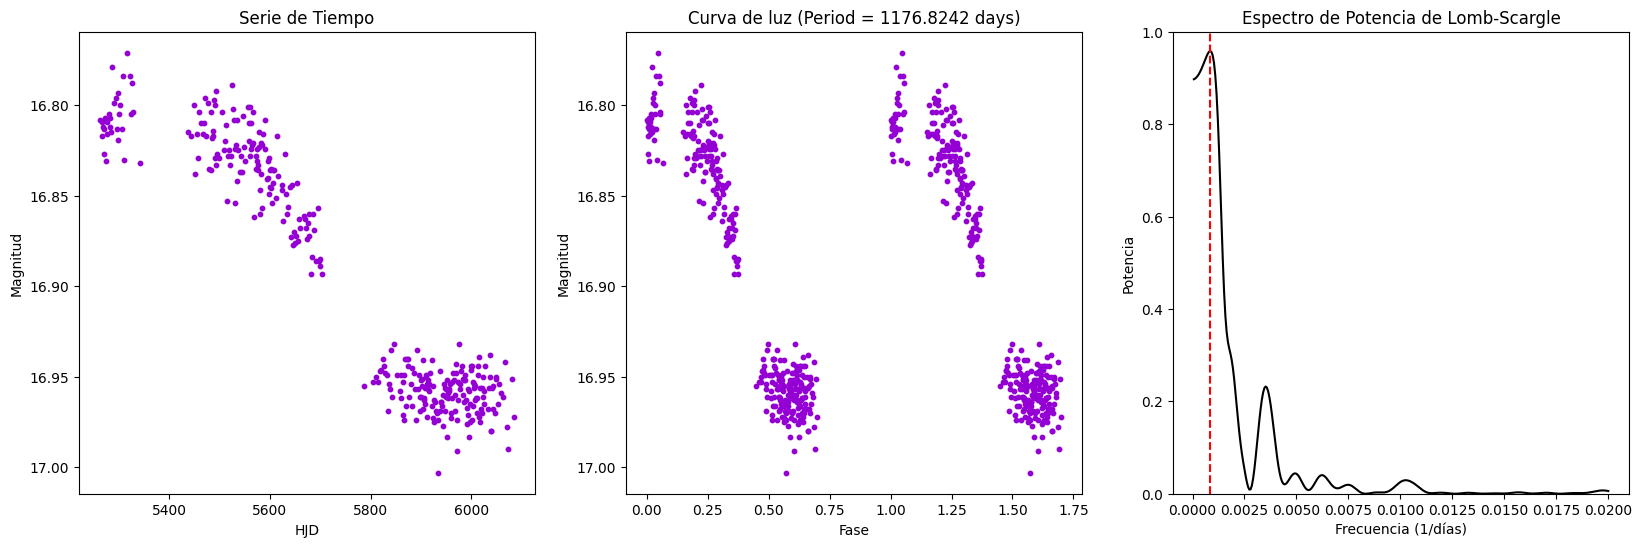

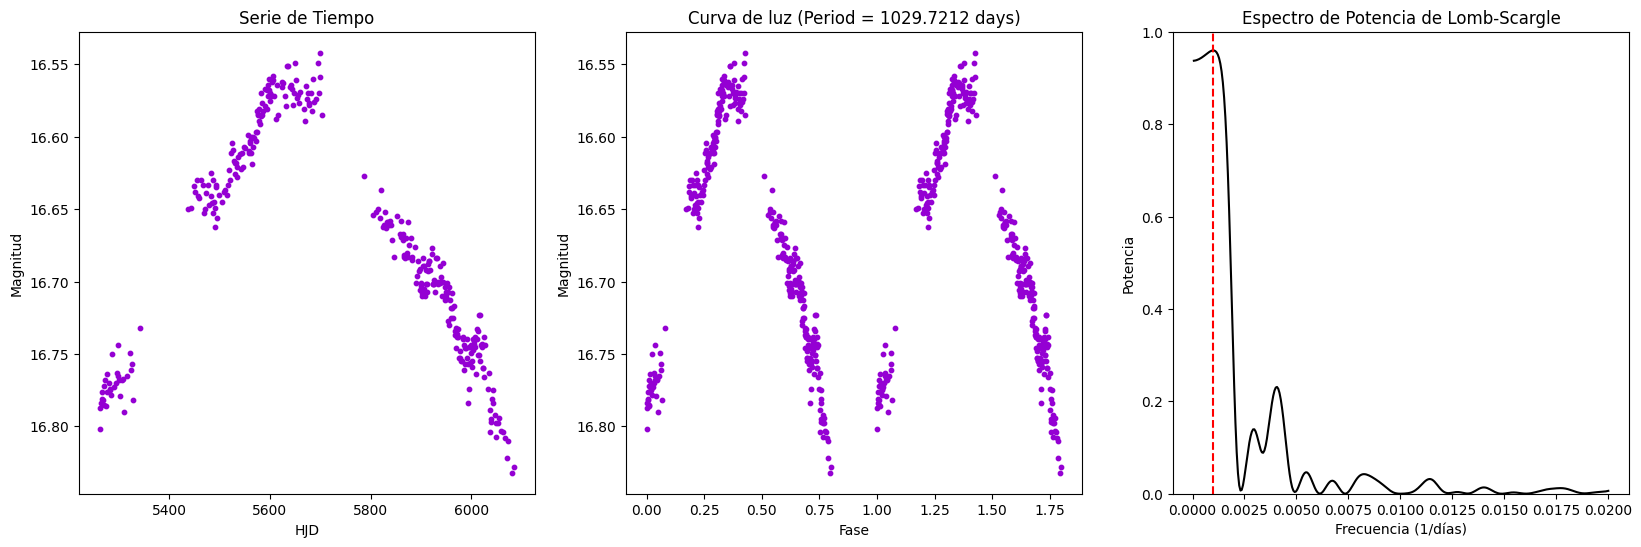

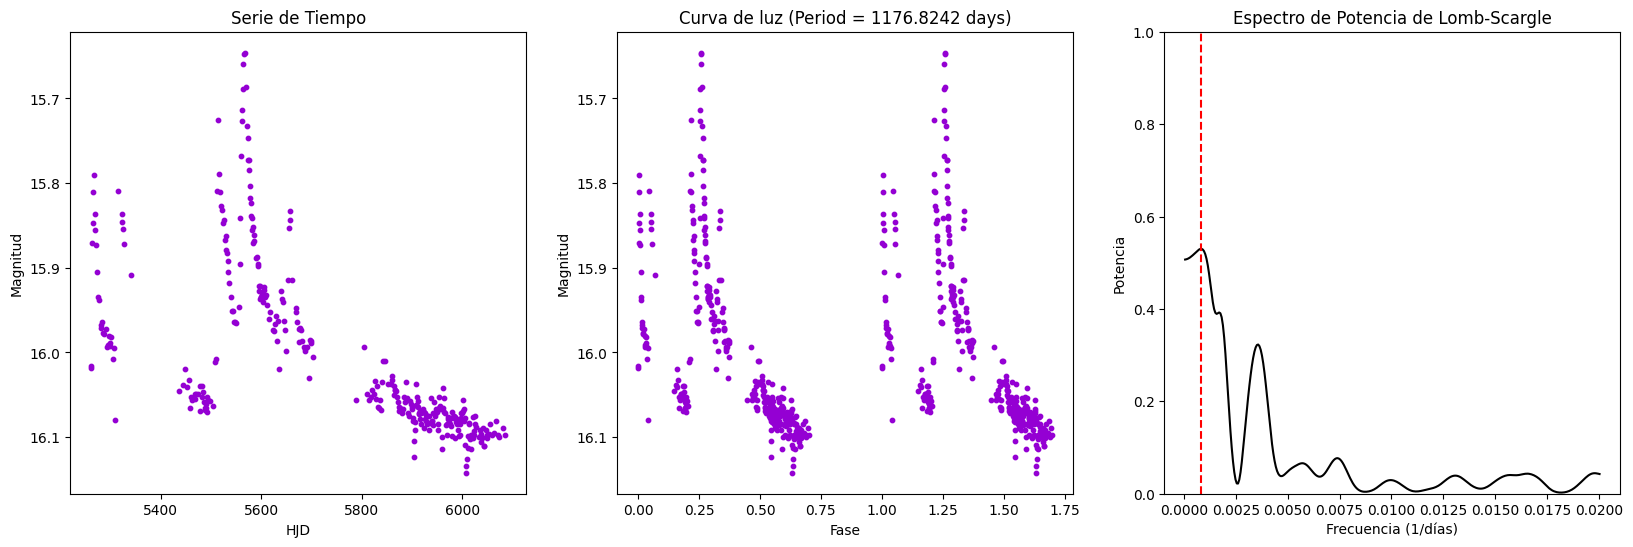

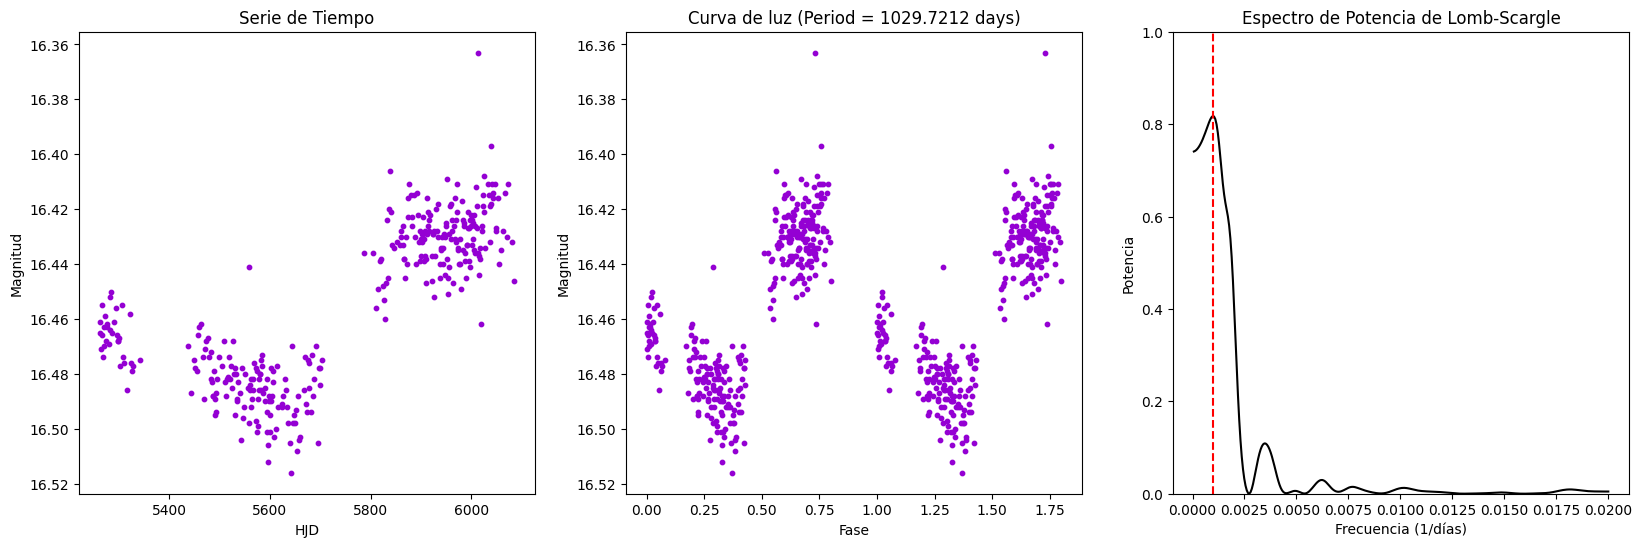

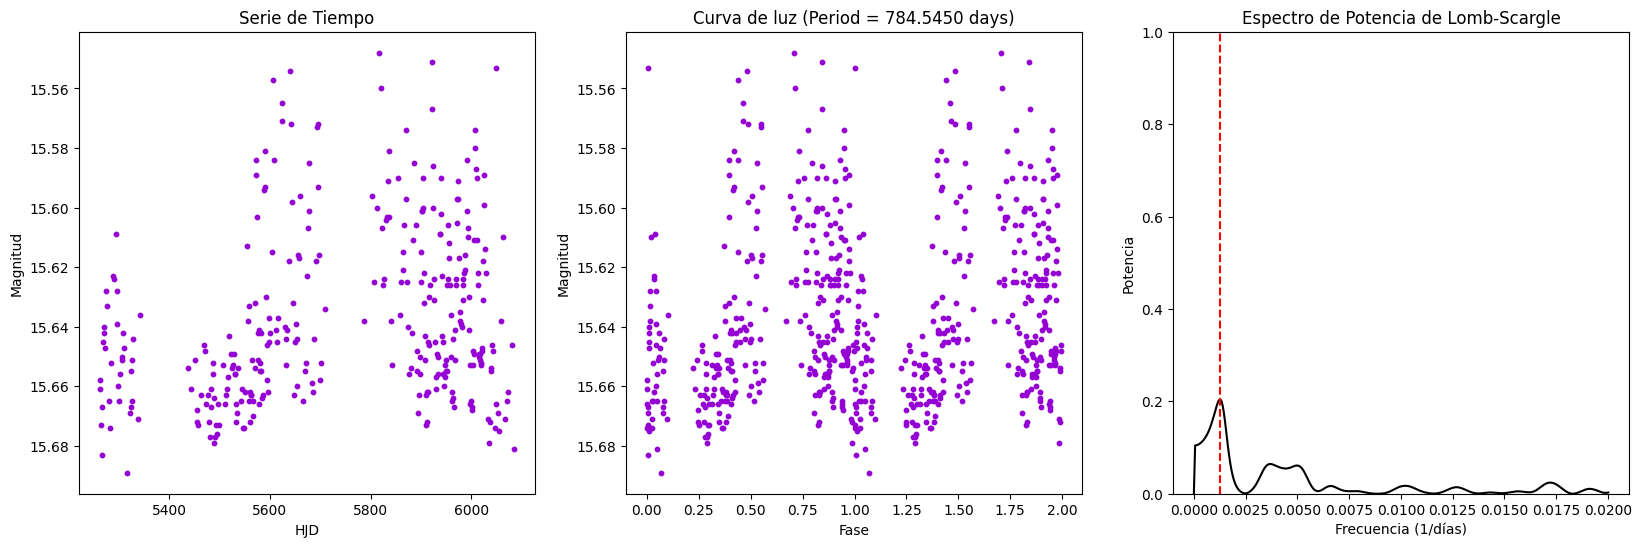

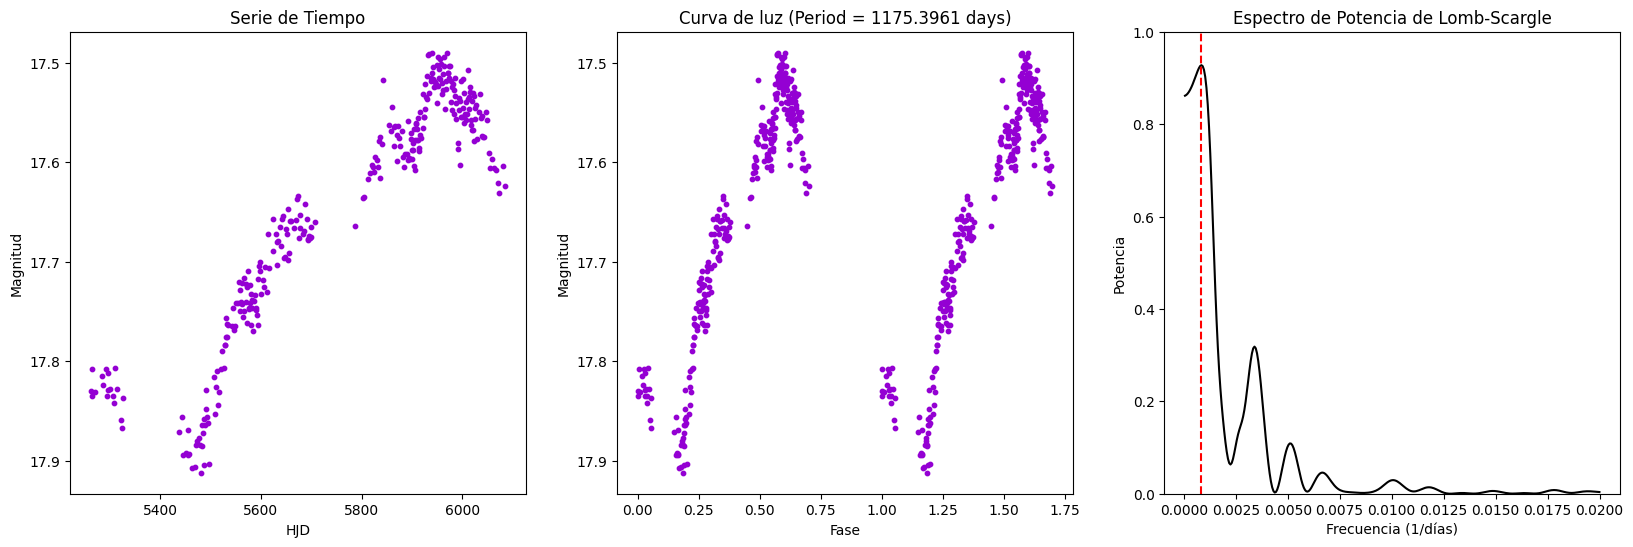

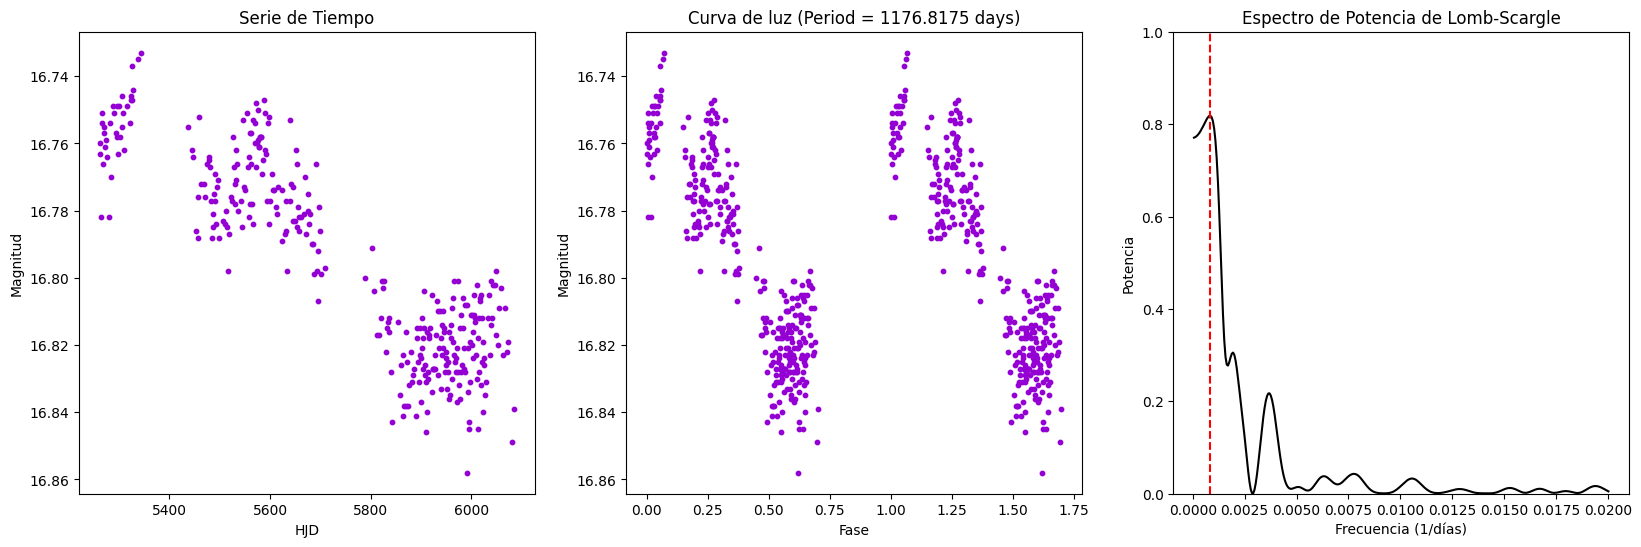

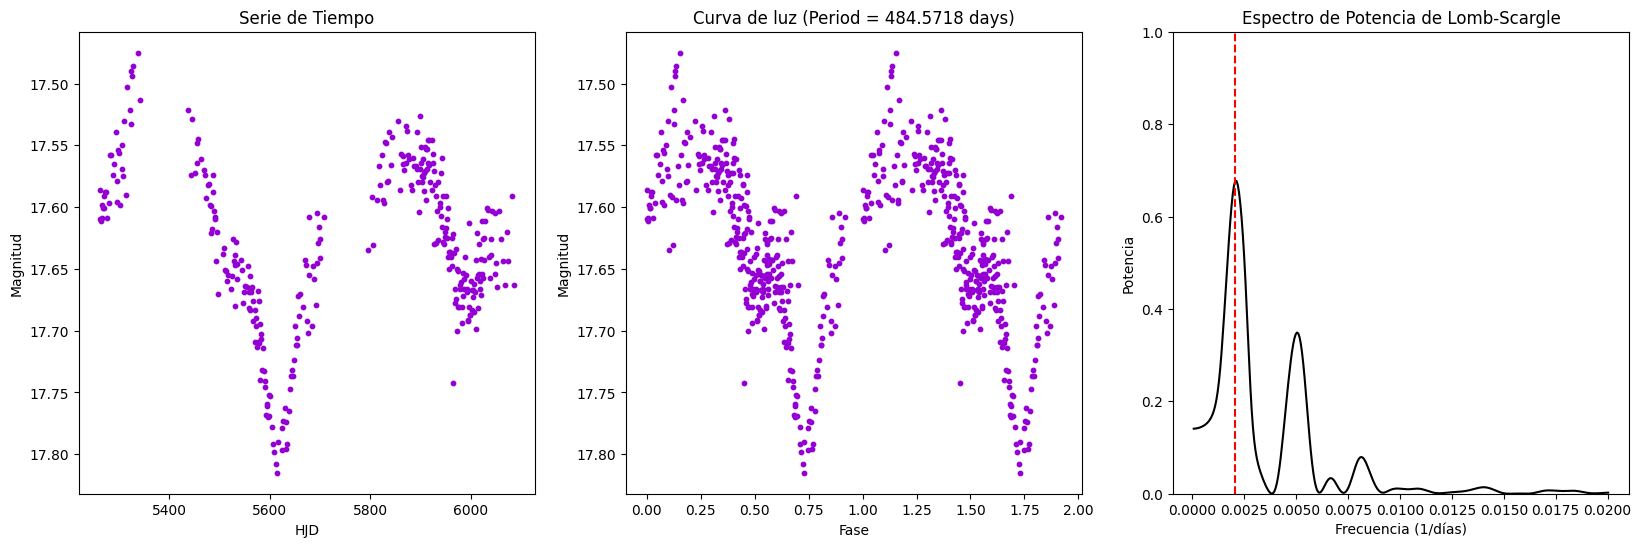

In [2]:
#ESTRELLAS MIRA:
carptea_i = 'Be_GSEP'
dfs=[]
for archivo in os.listdir(carptea_i):
    i=1
    globals()[f"df_{i}"] = pd.read_csv(os.path.join(carptea_i, archivo),sep = r"\s+", header=None)
    dfs.append(globals()[f"df_{i}"])
    i+=1

def phase_fold(hjd, period):
    return ((hjd-hjd[0]) % period) / period

for df in dfs:
    df.columns = ['hjd', 'mag', 'err']
    mags = df['mag'].values
    hjd = df['hjd'].values
    plt.figure(figsize=(20, 6))
    plt.subplot(1,3,1)
    plt.scatter(hjd, mags, s=10, c = 'darkviolet')
    plt.gca().invert_yaxis()
    plt.title('Serie de Tiempo')
    plt.xlabel('HJD')
    plt.ylabel('Magnitud')
    plt.subplot(1,3,2)
    frequency, power = LombScargle(hjd, mags).autopower(minimum_frequency=0.0, maximum_frequency=0.02, samples_per_peak=20)
    peaks, _ = find_peaks(power, height=0.1)
    peaks = peaks[np.argsort(power[peaks])[::-1]]
    power_max = peaks[0]
    period_max = 1 / frequency[power_max]
    phase = phase_fold(hjd, period_max)
    plt.scatter(phase, mags, s=10, c = 'darkviolet')
    plt.scatter(phase + 1, mags, s=10, c = 'darkviolet')
    plt.gca().invert_yaxis()
    plt.title(f'Curva de luz (Period = {period_max:.4f} days)')
    plt.xlabel('Fase')
    plt.ylabel('Magnitud')
    plt.subplot(1,3,3)
    plt.plot(frequency, power, c = 'black')
    plt.title('Espectro de Potencia de Lomb-Scargle')
    plt.xlabel('Frecuencia (1/días)')
    plt.ylabel('Potencia')
    plt.ylim(0,1)
    plt.axvline(x=frequency[power_max], color='red', linestyle='--', label=f'Frecuencia Máxima: {frequency[power_max]:.4f} 1/días')
    plt.show()

### Gamma-Cas

In [4]:
df = pd.read_csv("gamma cas_s_all.csv")

time = df['time'].values
mag = df['mag'].values

In [23]:
frequency, power = LombScargle(time, mag).autopower(minimum_frequency=0.01, maximum_frequency=10)

peaks, _ = find_peaks(power, height=0.1)
peaks = peaks[np.argsort(power[peaks])[::-1]]
power_max = peaks[2]
period_max = 1 / frequency[power_max]

print("Periodo encontrado:", period_max)

Periodo encontrado: 45.73911177005773


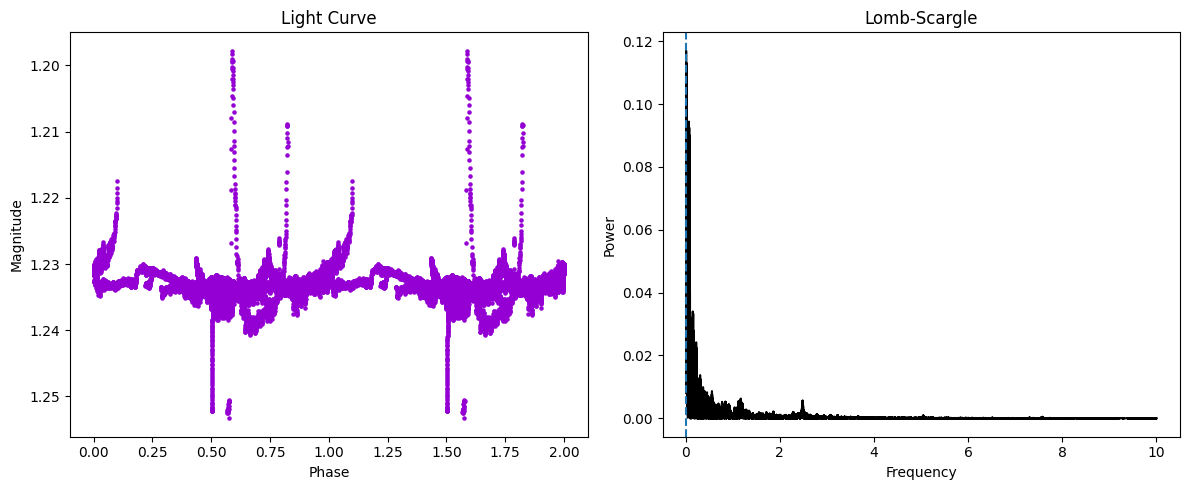

In [24]:
phase = ((time-time[0]) % period_max) / period_max

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(phase, mag, s=5, color='darkviolet')
axs[0].scatter(phase+1.0, mag, s=5, color='darkviolet')

axs[0].invert_yaxis()
axs[0].set_xlabel("Phase")
axs[0].set_ylabel("Magnitude")
axs[0].set_title("Light Curve")

axs[1].plot(frequency, power, color='black')
axs[1].set_xlabel("Frequency")
axs[1].set_ylabel("Power")
axs[1].set_title("Lomb-Scargle")

axs[1].axvline(best_frequency, linestyle='--')

plt.tight_layout()
plt.show()

In [27]:
from scipy.signal import hilbert

mag_detrended = mag - np.mean(mag)
analytic_signal = hilbert(mag_detrended)

# Envolvente
envelope = np.abs(analytic_signal)

frequency_env, power_env = LombScargle(time, envelope).autopower()

best_freq_env = frequency_env[np.argmax(power_env)]
period_env = 1 / best_freq_env

print("Periodo de la envolvente:", period_env)

Periodo de la envolvente: 171.68300426605842


In [28]:
#Alternativa para cadencias irregulares

from scipy.signal import savgol_filter

smoothed = savgol_filter(mag, window_length=101, polyorder=3)
residual = mag - smoothed

analytic_signal = hilbert(residual)

# Envolvente
envelope = np.abs(analytic_signal)

frequency_env, power_env = LombScargle(time, envelope).autopower()

best_freq_env = frequency_env[np.argmax(power_env)]
period_env = 1 / best_freq_env

print("Periodo de la envolvente:", period_env)

Periodo de la envolvente: 189.0247218686906


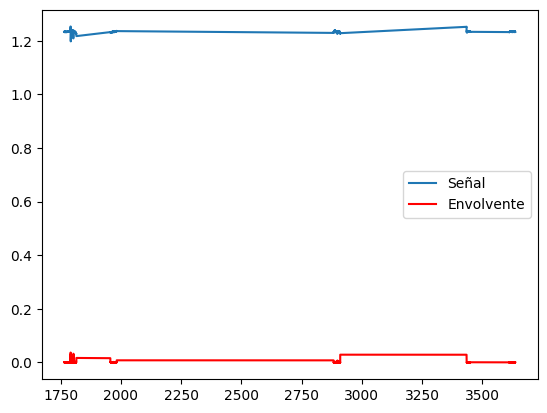

In [29]:
plt.figure()
plt.plot(time, mag, label="Señal")
plt.plot(time, envelope, label="Envolvente", color='red')
plt.legend()
plt.show()